# Factories Data Inspection

In [71]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [72]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [73]:
df_factories= pd.read_csv("F1_4_Air_Releases_Facilities.csv")

## Basic Structure

> This section explores the overall structure of the factories dataset. This includes:
- Number of rows and columns
- Column names
- Data types
- First observations of the dataset

---




In [74]:
print(f"Shape: {df_factories.shape[0]:,} rows x {df_factories.shape[1]} columns")
print(f"\nColumns: {list(df_factories.columns)}")
print(f"\nData types:")
print(df_factories.dtypes)

Shape: 372,206 rows x 16 columns

Columns: ['PublicationDate', 'countryName', 'reportingYear', 'EPRTR_SectorCode', 'EPRTR_SectorName', 'EPRTRAnnexIMainActivity', 'FacilityInspireId', 'facilityName', 'city', 'Longitude', 'Latitude', 'addressConfidentialityReason', 'TargetRelease', 'Pollutant', 'Releases', 'confidentialityReason']

Data types:
PublicationDate                  object
countryName                      object
reportingYear                     int64
EPRTR_SectorCode                float64
EPRTR_SectorName                 object
EPRTRAnnexIMainActivity          object
FacilityInspireId                object
facilityName                     object
city                             object
Longitude                       float64
Latitude                        float64
addressConfidentialityReason     object
TargetRelease                    object
Pollutant                        object
Releases                        float64
confidentialityReason            object
dtype: object


### First & Last Rows

In [75]:
df_factories.head()

,PublicationDate,countryName,reportingYear,EPRTR_SectorCode,EPRTR_SectorName,EPRTRAnnexIMainActivity,FacilityInspireId,facilityName,city,Longitude,Latitude,addressConfidentialityReason,TargetRelease,Pollutant,Releases,confidentialityReason
0,2026/02/13,Germany,2013,1.0,Energy sector,1(e),https://registry.gdi-de.org/id/de.nw.inspire.p...,RWE Power AG-Fabrik Fortuna Nord,Bergheim,6.658050,50.986950,NaN,AIR,Sulphur oxides (SOX),824000.0,NaN
1,2026/02/13,Sweden,2020,7.0,Intensive livestock production and aquaculture,7(a)(i),SE.CAED/10017896.Facility,Skåneägg Produktion AB,MÖRARP,12.849550,56.053160,NaN,AIR,Ammonia (NH3),16300.0,NaN
2,2026/02/13,Romania,2013,5.0,Waste and wastewater management,5(d),RO.CAED/104TL0001.FACILITY,SC ECOREC SA,TULCEA,28.769671,45.190459,NaN,AIR,Methane (CH4),269000.0,NaN
3,2026/02/13,Italy,2021,7.0,Intensive livestock production and aquaculture,7(a),IT.CAED/370602036.FACILITY,RONCHETRIN 1,GAZZO VERONESE,11.106667,45.123611,NaN,AIR,Ammonia (NH3),31920.0,NaN
4,2026/02/13,Czechia,2007,1.0,Energy sector,1(c),CZ.MZP.U423/CZ14819275.FACILITY,energetika,Štětí,14.380370,50.462296,NaN,AIR,Sulphur oxides (SOX),507000.0,NaN


In [76]:
df_factories = df_factories[df_factories["countryName"] == "Italy"].copy()

In [77]:
df_factories = df_factories[(df_factories["reportingYear"].between(2021, 2024))
].copy()



## Summary Statistics
We compute summary statistics to get an overview of the numerical  and categorical variables:
- Mean, median, standard deviation
- Minimum and maximum values
- Distribution of emission quantities

This provides a quick understanding of the scale and variability of the data.

---


In [78]:
print(df_factories.describe())

print("\n" + "=" * 60)
print("3b. SUMMARY STATISTICS (Categorical)")
print("=" * 60)
print(df_factories.describe(include="object"))

       reportingYear  EPRTR_SectorCode    Longitude     Latitude      Releases
count    6867.000000       6863.000000  6796.000000  6796.000000  6.867000e+03
mean     2022.463230          4.928894    11.303383    44.033133  6.236431e+07
std         1.119529          2.518289     2.369998     2.238101  3.247260e+08
min      2021.000000          1.000000     7.291100    36.903056  1.020000e-04
25%      2021.000000          3.000000     9.766700    43.587200  1.225400e+04
50%      2022.000000          7.000000    10.845300    45.040550  2.360000e+04
75%      2023.000000          7.000000    12.474305    45.409900  2.158281e+05
max      2024.000000          9.000000    18.318000    46.655000  7.352727e+09

3b. SUMMARY STATISTICS (Categorical)
       PublicationDate countryName  \
count             6867        6867   
unique               1           1   
top         2026/02/13       Italy   
freq              6867        6867   

                                      EPRTR_SectorName  \
co

## 3. Missing Data
We analyze missing values in the dataset:
- Count of missing values per column
- Percentage of missing data

This step is crucial to identify potential data quality issues and decide how to handle them.

---

                              count  percent
confidentialityReason          6867   100.00
addressConfidentialityReason   6796    98.97
Longitude                        71     1.03
Latitude                         71     1.03
EPRTR_SectorCode                  4     0.06
EPRTR_SectorName                  4     0.06
EPRTRAnnexIMainActivity           4     0.06
PublicationDate                   0     0.00
facilityName                      0     0.00
FacilityInspireId                 0     0.00
countryName                       0     0.00
reportingYear                     0     0.00
city                              0     0.00
TargetRelease                     0     0.00
Pollutant                         0     0.00
Releases                          0     0.00


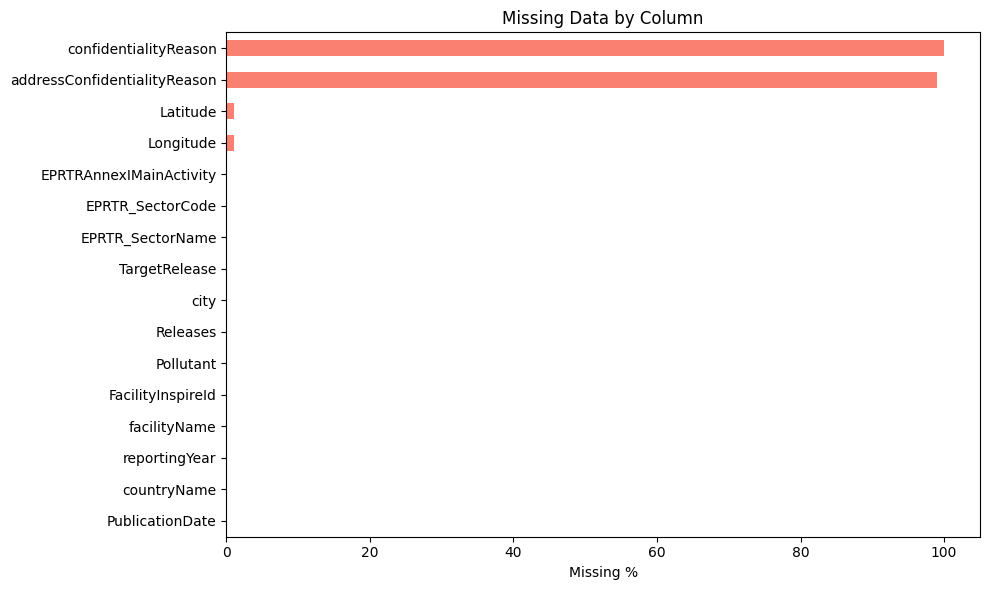

In [79]:
nulls = df_factories.isna().sum()
null_pct = (df_factories.isna().sum() / len(df_factories) * 100).round(2)
missing = pd.DataFrame({"count": nulls, "percent": null_pct}).sort_values("percent", ascending=False)
print(missing.to_string())

fig, ax = plt.subplots(figsize=(10, 6))
null_pcts = (df_factories.isna().sum() / len(df_factories) * 100).sort_values(ascending=True)
null_pcts.plot(kind="barh", ax=ax, color="salmon")
ax.set_xlabel("Missing %")
ax.set_title("Missing Data by Column")
plt.tight_layout()
plt.show()


## 4. Zero Values Inspection
We inspect columns for zero values, especially in emission-related fields:
- Identify whether zeros represent true absence of emissions or missing/incorrect data
- Evaluate their frequency and impact

---

In [80]:
import pandas as pd
import matplotlib.pyplot as plt

numeric_cols = df_factories.select_dtypes(include="number").columns
total_rows = len(df_factories)

print(f"Total rows: {total_rows:,}")
print(f"Numeric columns: {len(numeric_cols)}\n")

zero_summary = []
for col in numeric_cols:
    zero_count = (df_factories[col] == 0).sum()
    zero_pct = (zero_count / total_rows * 100)
    null_count = df_factories[col].isna().sum()
    zero_summary.append({
        "column": col,
        "zeros": zero_count,
        "zero_%": round(zero_pct, 2),
        "nulls": null_count,
        "total_valid": total_rows - null_count,
    })

zero_df = pd.DataFrame(zero_summary).sort_values("zero_%", ascending=False)
print(zero_df.to_string(index=False))



Total rows: 6,867
Numeric columns: 5

          column  zeros  zero_%  nulls  total_valid
   reportingYear      0     0.0      0         6867
EPRTR_SectorCode      0     0.0      4         6863
       Longitude      0     0.0     71         6796
        Latitude      0     0.0     71         6796
        Releases      0     0.0      0         6867


## 5. Unique Values per Column
We examine the number of unique values in each column:
- Identify categorical vs numerical features
- Detect potential identifiers (e.g., facility names)
- Spot columns with low variability

---

In [81]:
for col in df_factories.columns:
    print(f"  {col}: {df_factories[col].nunique()} unique")

  PublicationDate: 1 unique
  countryName: 1 unique
  reportingYear: 4 unique
  EPRTR_SectorCode: 9 unique
  EPRTR_SectorName: 9 unique
  EPRTRAnnexIMainActivity: 37 unique
  FacilityInspireId: 1638 unique
  facilityName: 1559 unique
  city: 1065 unique
  Longitude: 1578 unique
  Latitude: 1543 unique
  addressConfidentialityReason: 1 unique
  TargetRelease: 1 unique
  Pollutant: 38 unique
  Releases: 6050 unique
  confidentialityReason: 0 unique


## 6. Key Distributions
We analyze the distribution of important variables:
- Emission quantities
- Pollutant types
- Reporting years

This helps identify skewness, outliers, and dominant patterns in the data.

---

In [82]:
print("\nTop 15 Pollutants:")
print(df_factories["Pollutant"].value_counts().head(15))

print("\nReporting Year distribution:")
print(df_factories["reportingYear"].value_counts().sort_index())



Top 15 Pollutants:
Pollutant
Ammonia (NH3)                                     3270
Nitrogen oxides (NOX)                              788
Carbon dioxide (CO2)                               702
Methane (CH4)                                      364
Non-methane volatile organic compounds (NMVOC)     287
Sulphur oxides (SOX)                               152
Hydro-fluorocarbons (HFCS)                         136
Carbon monoxide (CO)                               135
Nitrous oxide (N2O)                                129
Zinc and compounds (as Zn)                         123
Benzene                                             94
Mercury and compounds (as Hg)                       81
Arsenic and compounds (as As)                       64
Nickel and compounds (as Ni)                        60
Cadmium and compounds (as Cd)                       50
Name: count, dtype: int64

Reporting Year distribution:
reportingYear
2021    1792
2022    1759
2023    1659
2024    1657
Name: count, dtype: int

## Visual Analysis - Plots

### 1. Reporting year Distributio

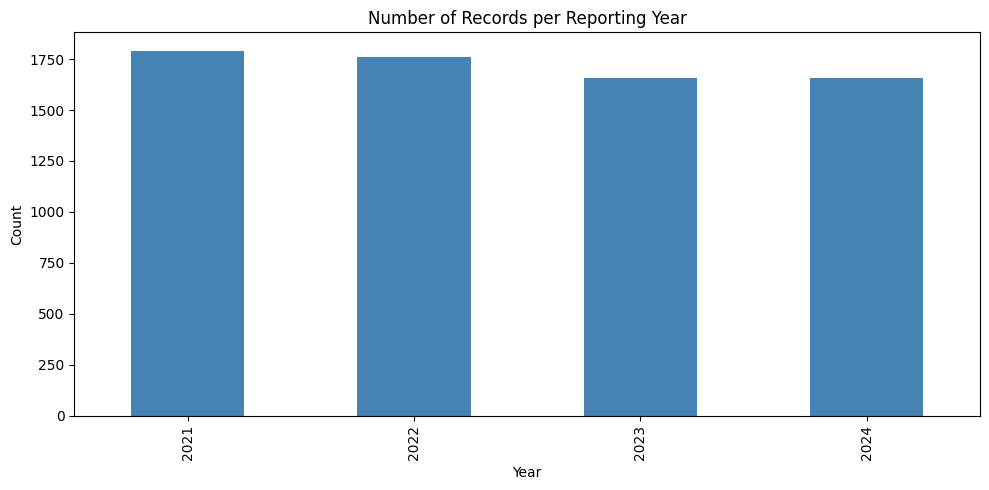

In [83]:

fig, ax = plt.subplots(figsize=(10, 5))
df_factories["reportingYear"].value_counts().sort_index().plot(kind="bar", ax=ax, color="steelblue")
ax.set_title("Number of Records per Reporting Year")
ax.set_xlabel("Year")
ax.set_ylabel("Count")
plt.tight_layout()
plt.show()




### 2. Top Pollutants

We visualize the most frequently reported or highest-emission pollutants:

- Identify major contributors to air pollution
- Compare emission levels across pollutants

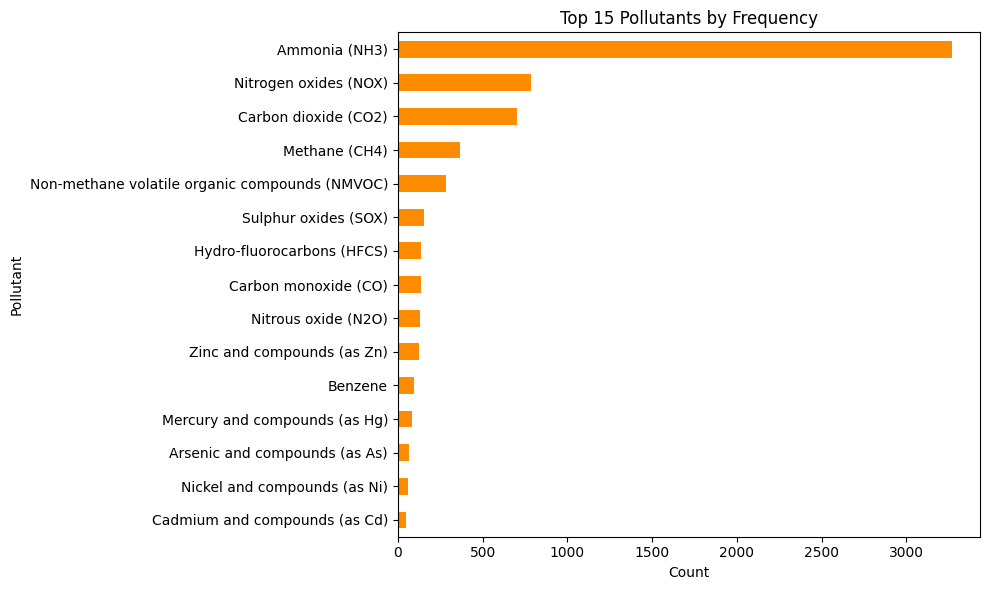

In [84]:
fig, ax = plt.subplots(figsize=(10, 6))
df_factories["Pollutant"].value_counts().head(15).plot(kind="barh", ax=ax, color="darkorange")
ax.set_title("Top 15 Pollutants by Frequency")
ax.set_xlabel("Count")
ax.invert_yaxis()
plt.tight_layout()
plt.show()


### 3. Geographic Distribution
We analyze the spatial distribution of factories:
- Map or coordinate-based visualization
- Identify pollution hotspots

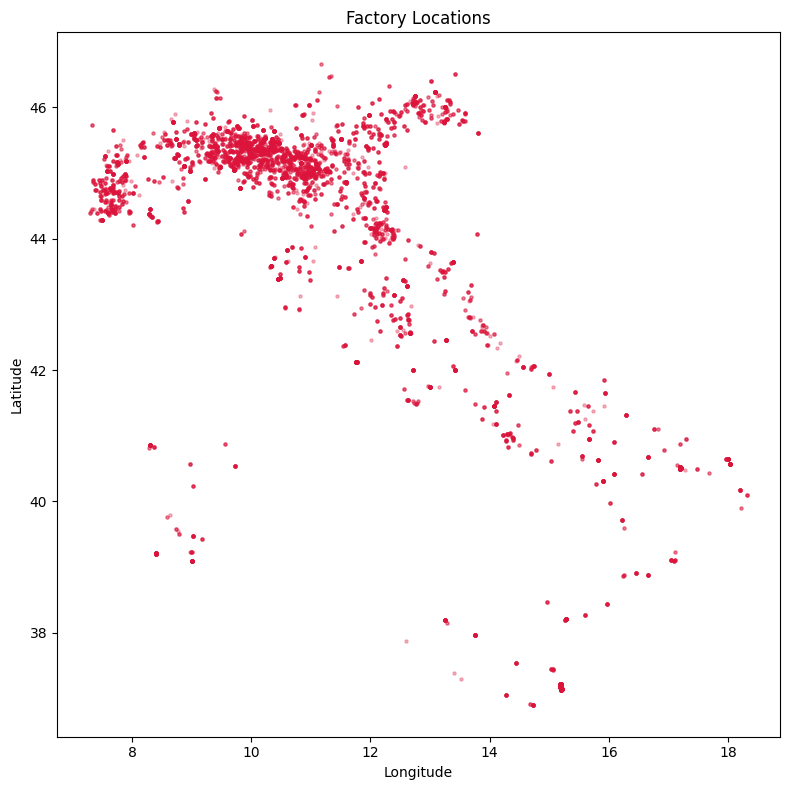


Geographic spread:
  Lat: 36.9031 to 46.6550
  Lon: 7.2911 to 18.3180


In [85]:
if "Latitude" in df_factories.columns and "Longitude" in df_factories.columns:
    fig, ax = plt.subplots(figsize=(8, 8))
    ax.scatter(df_factories["Longitude"], df_factories["Latitude"], alpha=0.3, s=5, c="crimson")
    ax.set_title("Factory Locations")
    ax.set_xlabel("Longitude")
    ax.set_ylabel("Latitude")
    plt.tight_layout()
    plt.show()

    print("\nGeographic spread:")
    print(f"  Lat: {df_factories['Latitude'].min():.4f} to {df_factories['Latitude'].max():.4f}")
    print(f"  Lon: {df_factories['Longitude'].min():.4f} to {df_factories['Longitude'].max():.4f}")

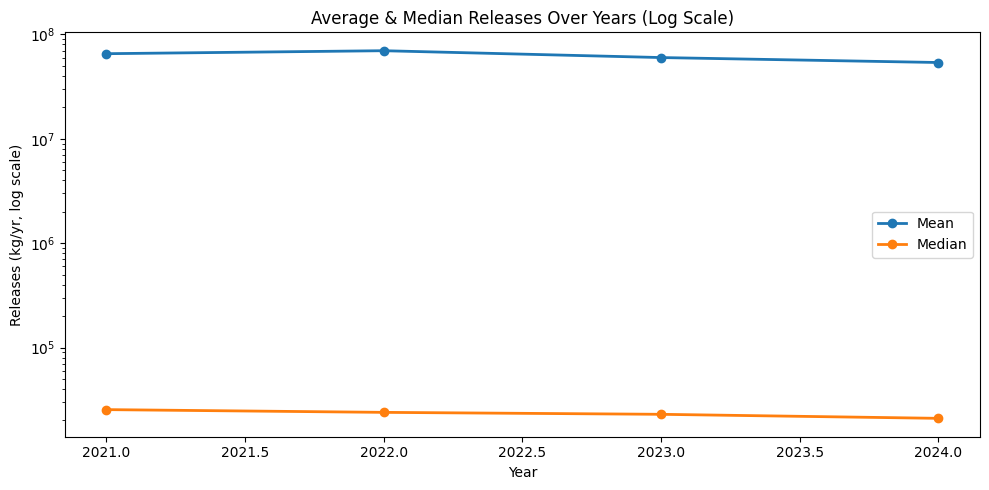

In [86]:
if "Releases" in df_factories.columns:
    fig, ax = plt.subplots(figsize=(10, 5))
    yearly = df_factories.groupby("reportingYear")["Releases"].agg(["mean", "median", "sum"])
    yearly[["mean", "median"]].plot(ax=ax, marker="o", linewidth=2)
    ax.set_yscale("log")
    ax.set_title("Average & Median Releases Over Years (Log Scale)")
    ax.set_xlabel("Year")
    ax.set_ylabel("Releases (kg/yr, log scale)")
    ax.legend(["Mean", "Median"])
    plt.tight_layout()
    plt.show()

In [87]:
print(df_factories["Releases"].quantile([0.25, 0.5, 0.75, 0.9, 0.95, 0.99]))

0.25    1.225400e+04
0.50    2.360000e+04
0.75    2.158281e+05
0.90    1.032553e+08
0.95    3.335806e+08
0.99    1.365920e+09
Name: Releases, dtype: float64


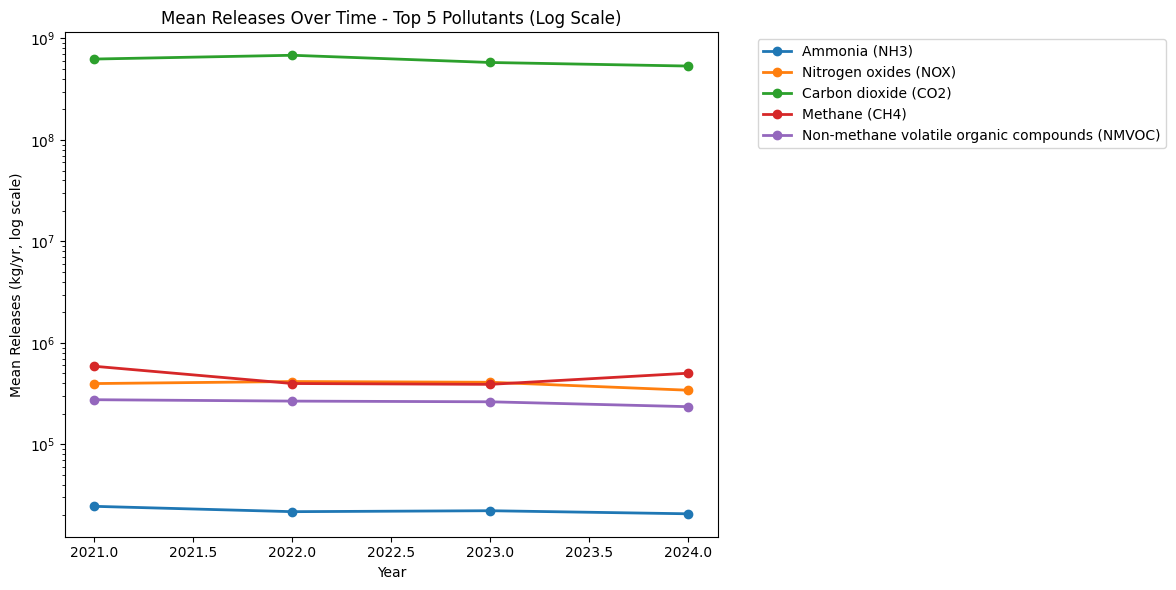

In [88]:
if "Releases" in df_factories.columns:
    top5 = df_factories["Pollutant"].value_counts().head(5).index
    fig, ax = plt.subplots(figsize=(12, 6))
    for poll in top5:
        subset = df_factories[df_factories["Pollutant"] == poll].groupby("reportingYear")["Releases"].mean()
        subset.plot(ax=ax, marker="o", label=poll, linewidth=2)
    ax.set_yscale("log")
    ax.set_title("Mean Releases Over Time - Top 5 Pollutants (Log Scale)")
    ax.set_xlabel("Year")
    ax.set_ylabel("Mean Releases (kg/yr, log scale)")
    ax.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
    plt.tight_layout()
    plt.show()

## Duplicate Check
We check for duplicate records:
- Exact duplicates
- Potential repeated entries for the same facility and pollutant

This ensures data consistency before cleaning.

---

In [89]:
print(f"Exact duplicate rows: {df_factories.duplicated().sum()}")



Exact duplicate rows: 0



---



















.

## Cleaning Factories Data

### Removing Irrelevant and Empty Columns
We begin by removing columns with little to no usable information:

- `confidentialityReason` → 100% missing values  
- `addressConfidentialityReason` → ~99% missing values  

These columns do not contribute meaningful insights and would only introduce noise into the analysis.

---


In [90]:
df_factories = df_factories.drop(columns=["confidentialityReason", "addressConfidentialityReason"])

print(f"Remaining columns: {df_factories.shape[1]}")
print(df_factories.columns.tolist())

Remaining columns: 14
['PublicationDate', 'countryName', 'reportingYear', 'EPRTR_SectorCode', 'EPRTR_SectorName', 'EPRTRAnnexIMainActivity', 'FacilityInspireId', 'facilityName', 'city', 'Longitude', 'Latitude', 'TargetRelease', 'Pollutant', 'Releases']


### Filtering for Relevant Industrial Activities
To align the dataset with the scope of the analysis, we investigate whether there are **power or energy-related facilities near Rome**.

- We filter `df_factories` for **energy-related activities** (e.g., power generation, combustion plants)
- This allows us to focus on facilities with the highest environmental impact

---

In [91]:
print(df_factories["EPRTRAnnexIMainActivity"].value_counts())

EPRTRAnnexIMainActivity
7(a)         2938
1(c)          867
3(c)          471
2(b)          338
1(a)          284
3(e)          225
5(d)          205
9(c)          185
7(a)(ii)      170
4(a)          157
4(e)          141
6(b)          121
5(b)          119
4(b)           91
2(e)           89
8(b)           83
7(a)(i)        81
5(a)           57
3(a)           36
2(a)           34
5(c)           26
2(d)           21
2(f)           19
4(c)           19
1(d)           13
3(g)           13
5(f)           12
7(a)(iii)      10
8(c)            9
9(a)            6
2(c)            5
5(g)            4
9(d)            4
9(b)            4
1(b)            3
7(b)            2
6(c)            1
Name: count, dtype: int64


In [92]:
print(df_factories["EPRTR_SectorName"].value_counts())

EPRTR_SectorName
Intensive livestock production and aquaculture                     3201
Energy sector                                                      1167
Mineral industry                                                    745
Production and processing of metals                                 506
Waste and wastewater management                                     423
Chemical industry                                                   408
Other activities                                                    199
Paper and wood production and processing                            122
Animal and vegetable products from the food and beverage sector      92
Name: count, dtype: int64


### Geographic Filtering (Lazio Area)
We restrict the dataset to facilities located within the **Lazio region** using approximate geographic boundaries.

- This ensures spatial relevance to Rome
- Removes facilities outside the area of interest
- Enables more accurate regional analysis

---

In [93]:
lazio = df_factories[
    (df_factories["Latitude"].between(40.0, 44.0)) &
    (df_factories["Longitude"].between(10.0, 14.5))
]
print(f"Facilities in centra italy area: {len(lazio)}")
print(lazio[["facilityName", "EPRTR_SectorName", "Latitude", "Longitude"]].drop_duplicates())

Facilities in centra italy area: 848
                                             facilityName  \
41                            CENTRALE TORREVALDALIGA SUD   
74      ACCIAI SPECIALI TERNI S.P.A. - stabilimento di...   
626                        Società Agricola Fileni S.r.l.   
1075                              Laminazione Sottile SpA   
1418                                  ALESSANDRO STASSANO   
...                                                   ...   
332392                                      ILSERV s.r.l.   
338630  UMBRAGROUP S.P.A. (Umbra Cuscinetti S.p.A.) - ...   
344399                                      ECOACCIAI SPA   
356305                           Acea Ambiente Srl - ul 5   
357584  Saxa Gres s.p.a. (ex Area Industrie Ceramiche ...   

                                      EPRTR_SectorName   Latitude  Longitude  
41                                       Energy sector  42.123100  11.765400  
74                 Production and processing of metals  42.566700  12.66

In [94]:
from math import radians, sin, cos, sqrt, atan2

def haversine(lat1, lon1, lat2, lon2):
    R = 6371
    dlat = radians(lat2 - lat1)
    dlon = radians(lon2 - lon1)
    a = sin(dlat/2)**2 + cos(radians(lat1)) * cos(radians(lat2)) * sin(dlon/2)**2
    return R * 2 * atan2(sqrt(a), sqrt(1-a))

# Rome center
rome_lat, rome_lon = 41.9028, 12.4964

energy_facilities = lazio[lazio["EPRTR_SectorName"] == "Energy sector"].copy()
energy_facilities["distance_km"] = energy_facilities.apply(
    lambda r: haversine(rome_lat, rome_lon, r["Latitude"], r["Longitude"]), axis=1
)

print(energy_facilities[["facilityName", "city", "Latitude", "Longitude", "distance_km"]].drop_duplicates().sort_values("distance_km").to_string())

                                                                  facilityName                    city  Latitude  Longitude  distance_km
14419                                    CENTRALE A CICLO COMBINATO DI APRILIA                 APRILIA  41.54940   12.63080    40.848517
85997                                    Centrale Termoelettrica di Colleferro              COLLEFERRO  41.76250   12.97170    42.356604
24093                                     Centrale compressione gas di Gallese                 GALLESE  42.36210   12.44320    51.259896
41                                                 CENTRALE TORREVALDALIGA SUD           CIVITAVECCHIA  42.12310   11.76540    65.171744
2310                                              Centrale Torrevaldaliga Nord           CIVITAVECCHIA  42.12750   11.75860    65.874727
37379                            Centrale termoelettrica di Montalto di Castro      MONTALTO DI CASTRO  42.35890   11.53380    94.196925
2965           Enel Produzione S.p.A. - I

In [95]:
df_factories.to_csv("factories_last.csv", index=False)

In [96]:
df_factories.columns

Index(['PublicationDate', 'countryName', 'reportingYear', 'EPRTR_SectorCode',
       'EPRTR_SectorName', 'EPRTRAnnexIMainActivity', 'FacilityInspireId',
       'facilityName', 'city', 'Longitude', 'Latitude', 'TargetRelease',
       'Pollutant', 'Releases'],
      dtype='object')

In [97]:
df_factories.head()

,PublicationDate,countryName,reportingYear,EPRTR_SectorCode,EPRTR_SectorName,EPRTRAnnexIMainActivity,FacilityInspireId,facilityName,city,Longitude,Latitude,TargetRelease,Pollutant,Releases
3,2026/02/13,Italy,2021,7.0,Intensive livestock production and aquaculture,7(a),IT.CAED/370602036.FACILITY,RONCHETRIN 1,GAZZO VERONESE,11.106667,45.123611,AIR,Ammonia (NH3),31920.0
6,2026/02/13,Italy,2021,7.0,Intensive livestock production and aquaculture,7(a),IT.CAED/370672013.FACILITY,ALZO S.N.C. DI BENEDETTI PIETRO E C. - SOCIETA...,VALEGGIO SUL MINCIO,10.739400,45.331700,AIR,Ammonia (NH3),27910.6
41,2026/02/13,Italy,2021,1.0,Energy sector,1(c),IT.CAED/000531001.FACILITY,CENTRALE TORREVALDALIGA SUD,CIVITAVECCHIA,11.765400,42.123100,AIR,Carbon dioxide (CO2),530453000.0
74,2026/02/13,Italy,2022,2.0,Production and processing of metals,2(b),IT.CAED/051002002.FACILITY,ACCIAI SPECIALI TERNI S.P.A. - stabilimento di...,TERNI,12.666700,42.566700,AIR,Nitrogen oxides (NOX),510200.0
92,2026/02/13,Italy,2022,5.0,Waste and wastewater management,5(d),IT.CAED/410592001.FACILITY,HERAMBIENTE S.R.L. - DISCARICA RIFIUTI NON PER...,ZOCCA,10.938600,44.340800,AIR,Methane (CH4),133874.2


### Dropping Non-Essential Columns
To simplify the dataset and focus on aggregate analysis, we remove the following columns:

- `TargetRelease` → Not relevant for current analysis  
- `city` → No variation (all observations are within Rome/Lazio)  
- `facilityName` → Individual identifiers not needed for aggregated insights  
- `FacilityInspireId` → Unique identifier, not analytically useful  
- `EPRTR_SectorCode` → Redundant with `EPRTR_SectorName`  

This step improves clarity and reduces dimensionality without losing meaningful information.

---

In [98]:
df_factories = df_factories.drop(columns=[
    "TargetRelease",
    "city",
    "facilityName",
    "FacilityInspireId",
    "EPRTR_SectorCode"
])

print(f"Remaining columns: {df_factories.columns.tolist()}")

Remaining columns: ['PublicationDate', 'countryName', 'reportingYear', 'EPRTR_SectorName', 'EPRTRAnnexIMainActivity', 'Longitude', 'Latitude', 'Pollutant', 'Releases']


### Distance from Rome Analysis

#### Objective
To better understand the spatial distribution of industrial facilities, we calculate the **distance of each facility from the center of Rome**.

---

#### Methodology
We use the **Haversine formula**, which computes the great-circle distance between two points on the Earth's surface based on their latitude and longitude.

- Reference point: **Rome city center**
  - Latitude: 41.9028  
  - Longitude: 12.4964  

- For each facility:
  - We calculate the distance (in kilometers) from Rome
  - Store the result in a new column: `distance_from_rome_km`

---

#### Why This Matters
This step allows us to:
- Identify how far industrial activities are located from Rome
- Detect clusters of factories near the city
- Support geographic filtering and environmental impact analysis

---

#### Results Overview
We examine:
- **Minimum and maximum distance** from Rome
- **Statistical distribution** (mean, median, quartiles)

This provides insight into whether facilities are:
- Concentrated near Rome  
- Evenly distributed  
- Located mostly in peripheral areas  

---


In [99]:
from math import radians, sin, cos, sqrt, atan2

def haversine(lat1, lon1, lat2, lon2):
    R = 6371
    dlat = radians(lat2 - lat1)
    dlon = radians(lon2 - lon1)
    a = sin(dlat/2)**2 + cos(radians(lat1)) * cos(radians(lat2)) * sin(dlon/2)**2
    return R * 2 * atan2(sqrt(a), sqrt(1-a))

# Rome center coordinates
rome_lat, rome_lon = 41.9028, 12.4964

# Calculate distance from Rome center for each facility
df_factories["distance_from_rome_km"] = df_factories.apply(
    lambda r: haversine(rome_lat, rome_lon, r["Latitude"], r["Longitude"]), axis=1
)

print(f"Distance range: {df_factories['distance_from_rome_km'].min():.1f} - {df_factories['distance_from_rome_km'].max():.1f} km")
print(f"\nDistance distribution:")
print(df_factories["distance_from_rome_km"].describe())

Distance range: 21.2 - 594.5 km

Distance distribution:
count    6796.000000
mean      389.103097
std       116.364141
min        21.188597
25%       352.172693
50%       422.336864
75%       461.965379
max       594.546462
Name: distance_from_rome_km, dtype: float64


In [100]:
df_factories.head()

,PublicationDate,countryName,reportingYear,EPRTR_SectorName,EPRTRAnnexIMainActivity,Longitude,Latitude,Pollutant,Releases,distance_from_rome_km
3,2026/02/13,Italy,2021,Intensive livestock production and aquaculture,7(a),11.106667,45.123611,Ammonia (NH3),31920.0,375.245942
6,2026/02/13,Italy,2021,Intensive livestock production and aquaculture,7(a),10.739400,45.331700,Ammonia (NH3),27910.6,406.637478
41,2026/02/13,Italy,2021,Energy sector,1(c),11.765400,42.123100,Carbon dioxide (CO2),530453000.0,65.171744
74,2026/02/13,Italy,2022,Production and processing of metals,2(b),12.666700,42.566700,Nitrogen oxides (NOX),510200.0,75.141874
92,2026/02/13,Italy,2022,Waste and wastewater management,5(d),10.938600,44.340800,Methane (CH4),133874.2,299.111506


In [101]:
df_factories = df_factories.drop(columns = "PublicationDate")

In [102]:
df_factories = df_factories.drop(columns = "countryName")

### Encoding Sector Information

#### Objective
To prepare the dataset for analysis, we transform the categorical variable `EPRTR_SectorName` into a numerical format.

---

#### 1. Creating Dummy Variables
We apply **one-hot encoding** to the `EPRTR_SectorName` column:

- Each sector is converted into a separate binary column
- Value = 1 → facility belongs to that sector  
- Value = 0 → otherwise  

We use:
- `drop_first=True` to **avoid multicollinearity**
  - This prevents redundancy by removing one reference category
  - Ensures more stable statistical analysis

---

In [103]:
dummies = pd.get_dummies(df_factories["EPRTR_SectorName"], prefix="Sector", drop_first=True)

df_factories = pd.concat([df_factories, dummies], axis=1)
df_factories = df_factories.drop(columns=["EPRTR_SectorName"])

print(f"Shape: {df_factories.shape}")
print(f"Columns: {df_factories.columns.tolist()}")

Shape: (6867, 15)
Columns: ['reportingYear', 'EPRTRAnnexIMainActivity', 'Longitude', 'Latitude', 'Pollutant', 'Releases', 'distance_from_rome_km', 'Sector_Chemical industry', 'Sector_Energy sector', 'Sector_Intensive livestock production and aquaculture', 'Sector_Mineral industry', 'Sector_Other activities', 'Sector_Paper and wood production and processing', 'Sector_Production and processing of metals', 'Sector_Waste and wastewater management']


### 2. Converting Boolean to Numeric
The generated dummy variables are initially in **True/False format**.

- We convert them to **0/1 representation**:
  - `True → 1`
  - `False → 0`

This ensures:
- Compatibility with machine learning models
- Consistency across numerical features

---


In [104]:
dummy_cols = [c for c in df_factories.columns if c.startswith("Sector_")]
df_factories[dummy_cols] = df_factories[dummy_cols].astype(int)

print(df_factories[dummy_cols].head())

    Sector_Chemical industry  Sector_Energy sector  \
3                          0                     0   
6                          0                     0   
41                         0                     1   
74                         0                     0   
92                         0                     0   

    Sector_Intensive livestock production and aquaculture  \
3                                                   1       
6                                                   1       
41                                                  0       
74                                                  0       
92                                                  0       

    Sector_Mineral industry  Sector_Other activities  \
3                         0                        0   
6                         0                        0   
41                        0                        0   
74                        0                        0   
92                        0 

In [105]:
df_factories.head()

,reportingYear,EPRTRAnnexIMainActivity,Longitude,Latitude,Pollutant,Releases,distance_from_rome_km,Sector_Chemical industry,Sector_Energy sector,Sector_Intensive livestock production and aquaculture,Sector_Mineral industry,Sector_Other activities,Sector_Paper and wood production and processing,Sector_Production and processing of metals,Sector_Waste and wastewater management
3,2021,7(a),11.106667,45.123611,Ammonia (NH3),31920.0,375.245942,0,0,1,0,0,0,0,0
6,2021,7(a),10.739400,45.331700,Ammonia (NH3),27910.6,406.637478,0,0,1,0,0,0,0,0
41,2021,1(c),11.765400,42.123100,Carbon dioxide (CO2),530453000.0,65.171744,0,1,0,0,0,0,0,0
74,2022,2(b),12.666700,42.566700,Nitrogen oxides (NOX),510200.0,75.141874,0,0,0,0,0,0,1,0
92,2022,5(d),10.938600,44.340800,Methane (CH4),133874.2,299.111506,0,0,0,0,0,0,0,1


In [106]:
df_factories.to_csv("factories_last_1.csv", index=False)

#Air Quality Data Inspection


## Role of Air Quality Data in the Project

This dataset allows us to:

- Measure real-world pollution levels (e.g., NO₂, PM10, PM2.5)  
- Analyze how pollution evolves over time  
- Compare pollution across different monitoring stations  
- Identify trends and potential environmental risks  

---

### Connection to Factories Data
The integration of air quality data with factories data enables a more comprehensive analysis:

- Factories → represent **pollution sources**  
- Air quality stations → represent **pollution outcomes**  

By combining both, we can:
- Explore relationships between industrial activity and air pollution  
- Identify whether areas with more industrial facilities show higher pollution levels  
- Support data-driven environmental insights  

---

### Analytical Value
Using air quality data strengthens the project by:

- Providing **empirical evidence** of pollution  
- Enabling **temporal analysis** (trends over years)  
- Supporting **visual and statistical exploration**  
- Enhancing the credibility of conclusions  

---

In this project, air quality data complements industrial emissions data, allowing us to move from:
- *“Who is emitting?”* → to → *“What is the actual environmental impact?”*

In [107]:
import pandas as pd

files = ["DataExtract 4.csv","DataExtract 5.csv","DataExtract 6.csv","DataExtract 7.csv"]

df_stats = pd.concat([pd.read_csv(f) for f in files], ignore_index=True)

## Basic statistics

We begin by examining the overall structure of the air quality dataset:

- Number of rows and columns  
- Column names and data types  
- Initial observations using sample rows  

This step helps us understand how the data is organized and what variables are available.

---

In [108]:
print(f"Shape: {df_stats.shape[0]:,} rows x {df_stats.shape[1]} columns")
print(f"\nData types:")
print(df_stats.dtypes)


Shape: 2,706 rows x 27 columns

Data types:
Country                                                            object
Air Quality Network                                                object
Air Quality Network Name                                           object
Air Quality Station EoI Code                                       object
Air Quality Station Name                                           object
Sampling Point Id                                                  object
Air Pollutant                                                      object
Air Pollutant Description                                          object
Data Aggregation Process Id                                        object
Data Aggregation Process                                           object
Year                                                                int64
Air Pollution Level                                               float64
Unit Of Air Pollution Level                                        o

In [109]:
df_stats

,Country,Air Quality Network,Air Quality Network Name,Air Quality Station EoI Code,Air Quality Station Name,Sampling Point Id,Air Pollutant,Air Pollutant Description,Data Aggregation Process Id,Data Aggregation Process,...,Longitude,Latitude,Altitude,City,City Code,City Population,Source Of Data Flow,Calculation Time,Link to raw data (only E1a/validated data from AQ e-Reporting),Observation Frequency
0,Italy,NET.IT112A,Regione Lazio,IT1835A,BUFALOTTA,SPO.IT1835A_7_UV-P_2006-12-06_00:00:00,O3,Ozone (air),P1Y-day-per50,1 year 50 %ile of daily values in a year,...,12.5337,41.9477,36.0,Roma ...,IT001C1 ...,2808293,E1a/validated data AQ e-Reporting,07/03/2026 22:59:18,https://eeadmz1batchservice02.blob.core.window...,hour
1,Italy,NET.IT112A,Regione Lazio,IT1835A,BUFALOTTA,SPO.IT1835A_7_UV-P_2006-12-06_00:00:00,O3,Ozone (air),P3Y,3 subsequent calendar years mean,...,12.5337,41.9477,36.0,Roma ...,IT001C1 ...,2808293,E1a/validated data AQ e-Reporting,07/03/2026 23:01:54,https://eeadmz1batchservice02.blob.core.window...,hour
2,Italy,NET.IT112A,Regione Lazio,IT1835A,BUFALOTTA,SPO.IT1835A_8_chemi_2019-03-18_00:00:00,NO2,Nitrogen dioxide (air),P1Y,Annual mean / 1 calendar year,...,12.5337,41.9477,36.0,Roma ...,IT001C1 ...,2808293,E1a/validated data AQ e-Reporting,07/03/2026 22:58:16,https://eeadmz1batchservice02.blob.core.window...,hour
3,Italy,NET.IT112A,Regione Lazio,IT1835A,BUFALOTTA,SPO.IT1835A_8_chemi_2019-03-18_00:00:00,NO2,Nitrogen dioxide (air),P1Y-day-per50,1 year 50 %ile of daily values in a year,...,12.5337,41.9477,36.0,Roma ...,IT001C1 ...,2808293,E1a/validated data AQ e-Reporting,07/03/2026 22:59:18,https://eeadmz1batchservice02.blob.core.window...,hour
4,Italy,NET.IT112A,Regione Lazio,IT1835A,BUFALOTTA,SPO.IT1835A_8_chemi_2019-03-18_00:00:00,NO2,Nitrogen dioxide (air),P1Y-hr-per50,1 year 50 percentile,...,12.5337,41.9477,36.0,Roma ...,IT001C1 ...,2808293,E1a/validated data AQ e-Reporting,07/03/2026 23:00:56,https://eeadmz1batchservice02.blob.core.window...,hour
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2701,Italy,NET.IT112A,Regione Lazio,IT1906A,ARENULA,SPO.IT1906A_7_UV-P_2009-11-29_00:00:00,O3,Ozone (air),P1Y-day-min,1 year day min,...,12.4754,41.8940,17.0,Roma ...,IT001C1 ...,2808293,E1a/validated data AQ e-Reporting,07/03/2026 22:59:10,https://eeadmz1batchservice02.blob.core.window...,hour
2702,Italy,NET.IT112A,Regione Lazio,IT1906A,ARENULA,SPO.IT1906A_7_UV-P_2009-11-29_00:00:00,O3,Ozone (air),P1Y-dmax-per93.15,1 year 93.15 percentile daily 8h maximum,...,12.4754,41.8940,17.0,Roma ...,IT001C1 ...,2808293,E1a/validated data AQ e-Reporting,07/03/2026 22:59:57,https://eeadmz1batchservice02.blob.core.window...,hour
2703,Italy,NET.IT112A,Regione Lazio,IT1906A,ARENULA,SPO.IT1906A_7_UV-P_2009-11-29_00:00:00,O3,Ozone (air),P1Y-P1D-per99,1 year 99 percentile of daily means (P1D) or ....,...,12.4754,41.8940,17.0,Roma ...,IT001C1 ...,2808293,E1a/validated data AQ e-Reporting,07/03/2026 23:01:47,https://eeadmz1batchservice02.blob.core.window...,hour
2704,Italy,NET.IT112A,Regione Lazio,IT1906A,ARENULA,SPO.IT1906A_8_chemi_2008-02-03_00:00:00,NO2,Nitrogen dioxide (air),P1Y-hr-max,1 year hour max,...,12.4754,41.8940,17.0,Roma ...,IT001C1 ...,2808293,E1a/validated data AQ e-Reporting,07/03/2026 23:00:20,https://eeadmz1batchservice02.blob.core.window...,hour


## Summary Statistics
We compute summary statistics for numerical variables:

- Mean, median, and standard deviation  
- Minimum and maximum values  
- Distribution of pollutant measurements  

This provides a general overview of pollution levels and variability.

---

In [110]:
print(df_stats.describe())

print("\n" + "=" * 60)
print("2b. SUMMARY STATISTICS (Categorical)")
print("=" * 60)
df_stats.describe(include="object")

              Year  Air Pollution Level  Data Coverage  Verification  \
count  2706.000000          2706.000000    2706.000000        2706.0   
mean   2022.484479           821.140721      94.674523           1.0   
std       1.118133          3809.418096       3.518019           0.0   
min    2021.000000            -1.992000      83.840000           1.0   
25%    2021.000000             0.672250      92.900000           1.0   
50%    2022.000000            25.560000      94.810000           1.0   
75%    2023.000000            85.398000      97.605000           1.0   
max    2024.000000         36627.117000     100.000000           1.0   

         Longitude     Latitude     Altitude  City Population  
count  2706.000000  2706.000000  2706.000000           2706.0  
mean     12.504233    41.906535    33.359941        2808293.0  
std       0.036858     0.031844    12.110450              0.0  
min      12.447600    41.857700    17.000000        2808293.0  
25%      12.469600    41.883100

,Country,Air Quality Network,Air Quality Network Name,Air Quality Station EoI Code,Air Quality Station Name,Sampling Point Id,Air Pollutant,Air Pollutant Description,Data Aggregation Process Id,Data Aggregation Process,Unit Of Air Pollution Level,Air Quality Station Type,Air Quality Station Area,City,City Code,Source Of Data Flow,Calculation Time,Link to raw data (only E1a/validated data from AQ e-Reporting),Observation Frequency
count,2706,2706,2706,2706,2706,2706,2706,2706,2706,2706,2706,2706,2706,2706,2706,2706,2706,2706,2706
unique,1,1,1,10,10,55,11,11,51,50,3,2,1,1,1,1,51,55,1
top,Italy,NET.IT112A,Regione Lazio,IT0953A,VILLA ADA,SPO.IT1835A_7_UV-P_2006-12-06_00:00:00,NO2,Nitrogen dioxide (air),P1Y-day-per50,1 year 50 %ile of daily values in a year,ug/m3,Background,Urban,Roma ...,IT001C1 ...,E1a/validated data AQ e-Reporting,07/03/2026 22:59:18,https://eeadmz1batchservice02.blob.core.window...,hour
freq,2706,2706,2706,528,528,116,760,760,218,218,2206,1830,2706,2706,2706,2706,218,116,2706


## Missing Data
We analyze missing values across the dataset:

- Count and percentage of missing values per column  
- Identification of incomplete records  

This step is essential for assessing data quality and guiding cleaning decisions.

---

In [111]:
nulls = df_stats.isna().sum()
null_pct = (df_stats.isna().sum() / len(df_stats) * 100).round(2)
missing = pd.DataFrame({"count": nulls, "percent": null_pct}).sort_values("percent", ascending=False)
print(missing.to_string())




                                                                count  percent
Country                                                             0      0.0
Air Quality Network                                                 0      0.0
Air Quality Network Name                                            0      0.0
Air Quality Station EoI Code                                        0      0.0
Air Quality Station Name                                            0      0.0
Sampling Point Id                                                   0      0.0
Air Pollutant                                                       0      0.0
Air Pollutant Description                                           0      0.0
Data Aggregation Process Id                                         0      0.0
Data Aggregation Process                                            0      0.0
Year                                                                0      0.0
Air Pollution Level                                 

## Key Distributions
We explore the distribution of key variables:

- Pollutant concentration levels  
- Measurement values across stations  
- Temporal patterns (e.g., yearly trends)  

This helps identify skewness, outliers, and dominant patterns.

---

In [112]:
print("\nPollutants:")
print(df_stats["Air Pollutant"].value_counts())

print("\nYear distribution:")
print(df_stats["Year"].value_counts().sort_index())

print("\nStation Names:")
print(df_stats["Air Quality Station Name"].value_counts())




Pollutants:
Air Pollutant
NO2               760
O3                696
NOX as NO2        320
NO                280
SO2               126
CO                104
C6H5-CH3           84
C6H5-C2H5          84
C6H6               84
m,p-C6H4(CH3)2     84
o-C6H4-(CH3)2      84
Name: count, dtype: int64

Year distribution:
Year
2021    687
2022    687
2023    666
2024    666
Name: count, dtype: int64

Station Names:
Air Quality Station Name
VILLA ADA            528
FERMI                328
BUFALOTTA            294
C.SO FRANCIA         276
CIPRO                252
CINECITTA            252
L.GO PERESTRELLO     252
ARENULA              252
L.GO MAGNA GRECIA    136
TIBURTINA            136
Name: count, dtype: int64


## 5. Visual Analysis (Plots)

### Pollutant Frequency
We visualize how frequently each pollutant appears in the dataset:

- Identify the most commonly measured pollutants  
- Understand dataset composition  

---

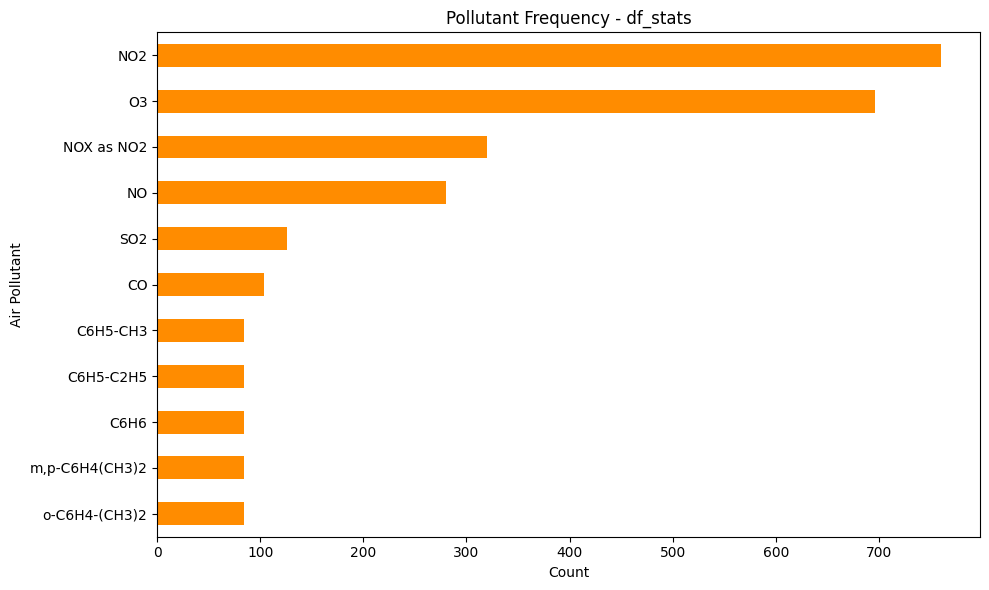

In [113]:
fig, ax = plt.subplots(figsize=(10, 6))
df_stats["Air Pollutant"].value_counts().plot(kind="barh", ax=ax, color="darkorange")
ax.set_title("Pollutant Frequency - df_stats")
ax.set_xlabel("Count")
ax.invert_yaxis()
plt.tight_layout()
plt.show()

###  Records per Station
We analyze the number of records for each monitoring station:

- Identify stations with the most data  
- Detect imbalances in data collection  

---

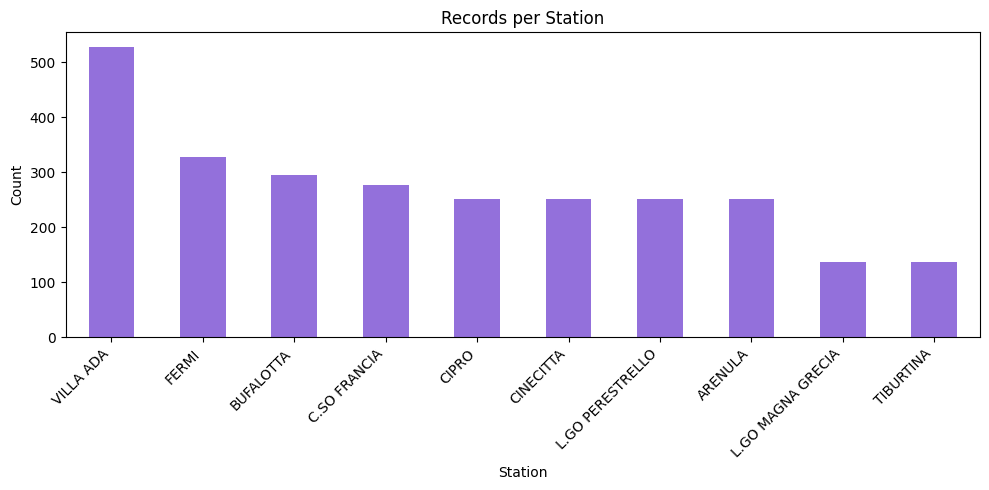

In [114]:
# 6d. Records per station
fig, ax = plt.subplots(figsize=(10, 5))
df_stats["Air Quality Station Name"].value_counts().plot(kind="bar", ax=ax, color="mediumpurple")
ax.set_title("Records per Station")
ax.set_xlabel("Station")
ax.set_ylabel("Count")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

### 5.3 Mean Pollution Levels Over Years
We examine trends in pollution over time:

- Compute average pollutant levels per year  
- Focus on the **top 5 most relevant pollutants**  

This allows us to:
- Observe long-term trends  
- Identify increases or decreases in pollution levels  
- Support environmental insights and policy discussion  

---

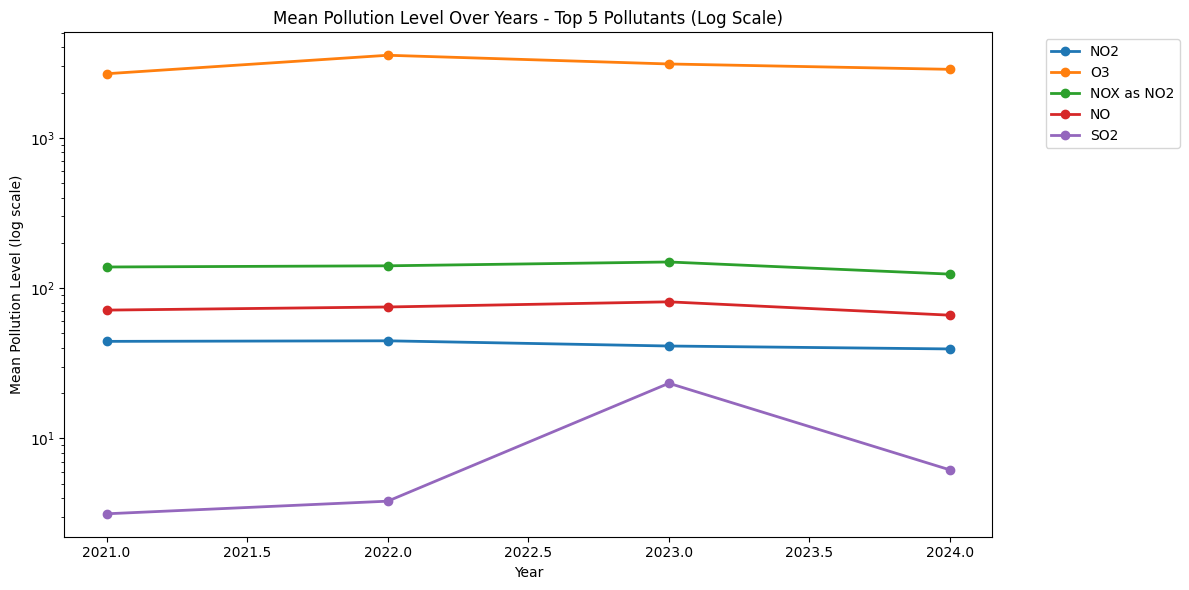

In [115]:
fig, ax = plt.subplots(figsize=(12, 6))
for poll in df_stats["Air Pollutant"].value_counts().head(5).index:
    sub = df_stats[df_stats["Air Pollutant"] == poll].groupby("Year")["Air Pollution Level"].mean()
    ax.plot(sub.index, sub.values, marker="o", linewidth=2, label=poll)
ax.set_yscale("log")
ax.set_title("Mean Pollution Level Over Years - Top 5 Pollutants (Log Scale)")
ax.set_xlabel("Year")
ax.set_ylabel("Mean Pollution Level (log scale)")
ax.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()


In [116]:
!pip install contextily

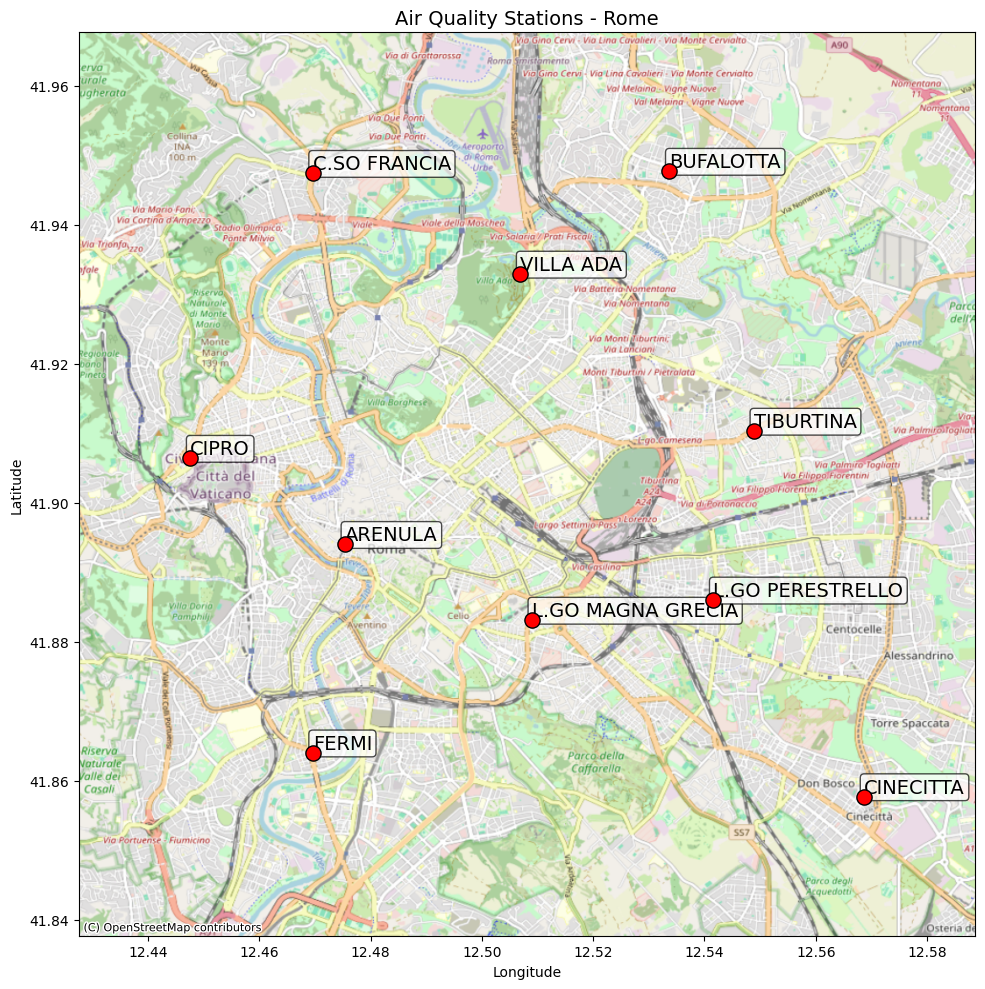

In [117]:
import contextily as ctx
import matplotlib.pyplot as plt

stations = df_stats[["Air Quality Station Name", "Latitude", "Longitude"]].drop_duplicates()

fig, ax = plt.subplots(figsize=(10, 10))
ax.scatter(stations["Longitude"], stations["Latitude"], s=120, c="red", zorder=5, edgecolors="black")

for _, row in stations.iterrows():
    ax.annotate(row["Air Quality Station Name"],
                (row["Longitude"], row["Latitude"]),
                fontsize=14, ha="left", va="bottom",
                bbox=dict(boxstyle="round,pad=0.2", fc="white", alpha=0.7))

# Add some padding around the points
pad = 0.02
ax.set_xlim(stations["Longitude"].min() - pad, stations["Longitude"].max() + pad)
ax.set_ylim(stations["Latitude"].min() - pad, stations["Latitude"].max() + pad)

# Add the real map as background
ctx.add_basemap(ax, crs="EPSG:4326", source=ctx.providers.OpenStreetMap.Mapnik)

ax.set_title("Air Quality Stations - Rome", fontsize=14)
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
plt.tight_layout()
plt.show()

##  Data Quality Assessment

### Zero Values Inspection
We analyze the presence of zero values in the dataset:

- Identify columns where pollutant concentrations are recorded as 0  
- Evaluate the frequency of zero values  
- Assess whether zeros represent:
  - True absence of pollution  
  - Measurement limitations or missing data proxies  

This step is crucial, as zero values in environmental data may not always reflect real conditions.

---

In [118]:
numeric_cols = df_stats.select_dtypes(include="number").columns
for col in numeric_cols:
    zero_count = (df_stats[col] == 0).sum()
    if zero_count > 0:
        print(f"  {col}: {zero_count} zeros ({zero_count/len(df_stats)*100:.2f}%)")


  Air Pollution Level: 424 zeros (15.67%)


### 2. Duplicate Records
We check for duplicate entries in the dataset:

- Identify fully duplicated rows  
- Detect repeated measurements for the same station, pollutant, and time period  

Removing duplicates ensures:
- Data consistency  
- Avoidance of biased results due to repeated observations  

---

In [119]:
print(f"Exact duplicate rows: {df_stats.duplicated().sum()}")



Exact duplicate rows: 0


### 3. Data Quality Summary
Based on the previous checks, we summarize the overall quality of the dataset:

- Impact and interpretation of zero values  
- Presence of duplicate records  
- Overall consistency of measurements  

This helps determine:
- Whether the dataset accurately reflects pollution levels  
- What preprocessing steps are required before further analysis  

---

In [120]:
print(f"  Total rows: {len(df_stats):,}")
print(f"  Columns: {df_stats.shape[1]}")
print(f"  Columns with nulls: {(df_stats.isna().sum() > 0).sum()}")
print(f"  Exact duplicates: {df_stats.duplicated().sum()}")
print(f"  Unique stations: {df_stats['Air Quality Station Name'].nunique()}")
print(f"  Unique sampling points: {df_stats['Sampling Point Id'].nunique()}")
print(f"  Unique pollutants: {df_stats['Air Pollutant'].nunique()}")
print(f"  Year range: {df_stats['Year'].min()} - {df_stats['Year'].max()}")
print(f"  Pollution Level range: {df_stats['Air Pollution Level'].min()} - {df_stats['Air Pollution Level'].max()}")

  Total rows: 2,706
  Columns: 27
  Columns with nulls: 0
  Exact duplicates: 0
  Unique stations: 10
  Unique sampling points: 55
  Unique pollutants: 11
  Year range: 2021 - 2024
  Pollution Level range: -1.992 - 36627.117


# air quality stats data cleaning

## Droppping :

-### Objective
To improve data quality and reduce redundancy, we remove columns that do not provide meaningful information for the analysis.

---

### Removing Columns with No Informational Value
The following columns are dropped because they contain **constant values across all observations**:

- `Country` → All values are *Italy*, no additional information  
- `Air Quality Network Name` → All values are *Regione Lazio*, no variation  
- `Air Quality Network` → Same network (*NET.IT112A*) for all stations  
- `Observation Frequency` → Identical value (*hourly*) across all rows  
- `Source Of Data Flow` → Same source for all entries  
- `City Population` → Constant value, no variability  
- `Air Quality Station Area` → All stations classified as *Urban*  

These variables do not contribute to differentiation or analysis.

---


In [121]:
df_stats = df_stats.drop(columns=[
    "Country",
    "Air Quality Network Name",
    "Air Quality Network",
    "Observation Frequency",
    "Source Of Data Flow",
    "City Population",
    "Air Quality Station Area",
    ])

print(f"Remaining columns: {df_stats.shape[1]}")

Remaining columns: 20



### Removing Redundant Identifiers
The following columns are removed because they duplicate existing information:

- `City Code` and `City` → Redundant, as city name is already available  
- `Air Quality Station EoI Code` → Encodes the same information as station name  

Removing redundant identifiers simplifies the dataset without losing meaningful content.

---

In [122]:
df_stats = df_stats.drop(columns=[
   "City Code",
    "City",
    "Air Quality Station EoI",
])

print(f"Remaining columns: {df_stats.shape[1]}")
print(df_stats.columns.tolist())

KeyError: "['Air Quality Station EoI'] not found in axis"

### Additional Column Removal

We further remove columns that do not contribute to the analysis:

- `Data Coverage` → Not relevant for the objectives of this analysis  
- `Verification` → Same verification status across all rows, no variation  

These variables do not provide additional analytical value and are excluded to streamline the dataset.

In [124]:
df_stats = df_stats.drop(columns=[
    "Data Coverage",
    "Verification",
    "Calculation Time"])

print(f"Remaining columns: {df_stats.shape[1]}")
print(df_stats.columns.tolist())

Remaining columns: 17
['Air Quality Station EoI Code', 'Air Quality Station Name', 'Sampling Point Id', 'Air Pollutant', 'Air Pollutant Description', 'Data Aggregation Process Id', 'Data Aggregation Process', 'Year', 'Air Pollution Level', 'Unit Of Air Pollution Level', 'Air Quality Station Type', 'Longitude', 'Latitude', 'Altitude', 'City', 'City Code', 'Link to raw data (only E1a/validated data from AQ e-Reporting)']


In [123]:
df_stats

,Air Quality Station EoI Code,Air Quality Station Name,Sampling Point Id,Air Pollutant,Air Pollutant Description,Data Aggregation Process Id,Data Aggregation Process,Year,Air Pollution Level,Unit Of Air Pollution Level,Data Coverage,Verification,Air Quality Station Type,Longitude,Latitude,Altitude,City,City Code,Calculation Time,Link to raw data (only E1a/validated data from AQ e-Reporting)
0,IT1835A,BUFALOTTA,SPO.IT1835A_7_UV-P_2006-12-06_00:00:00,O3,Ozone (air),P1Y-day-per50,1 year 50 %ile of daily values in a year,2021,42.741,ug/m3,95.07,1,Background,12.5337,41.9477,36.0,Roma ...,IT001C1 ...,07/03/2026 22:59:18,https://eeadmz1batchservice02.blob.core.window...
1,IT1835A,BUFALOTTA,SPO.IT1835A_7_UV-P_2006-12-06_00:00:00,O3,Ozone (air),P3Y,3 subsequent calendar years mean,2021,43.681,ug/m3,97.26,1,Background,12.5337,41.9477,36.0,Roma ...,IT001C1 ...,07/03/2026 23:01:54,https://eeadmz1batchservice02.blob.core.window...
2,IT1835A,BUFALOTTA,SPO.IT1835A_8_chemi_2019-03-18_00:00:00,NO2,Nitrogen dioxide (air),P1Y,Annual mean / 1 calendar year,2021,32.305,ug/m3,91.38,1,Background,12.5337,41.9477,36.0,Roma ...,IT001C1 ...,07/03/2026 22:58:16,https://eeadmz1batchservice02.blob.core.window...
3,IT1835A,BUFALOTTA,SPO.IT1835A_8_chemi_2019-03-18_00:00:00,NO2,Nitrogen dioxide (air),P1Y-day-per50,1 year 50 %ile of daily values in a year,2021,31.218,ug/m3,92.88,1,Background,12.5337,41.9477,36.0,Roma ...,IT001C1 ...,07/03/2026 22:59:18,https://eeadmz1batchservice02.blob.core.window...
4,IT1835A,BUFALOTTA,SPO.IT1835A_8_chemi_2019-03-18_00:00:00,NO2,Nitrogen dioxide (air),P1Y-hr-per50,1 year 50 percentile,2021,28.348,ug/m3,91.38,1,Background,12.5337,41.9477,36.0,Roma ...,IT001C1 ...,07/03/2026 23:00:56,https://eeadmz1batchservice02.blob.core.window...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2701,IT1906A,ARENULA,SPO.IT1906A_7_UV-P_2009-11-29_00:00:00,O3,Ozone (air),P1Y-day-min,1 year day min,2024,2.928,ug/m3,97.81,1,Background,12.4754,41.8940,17.0,Roma ...,IT001C1 ...,07/03/2026 22:59:10,https://eeadmz1batchservice02.blob.core.window...
2702,IT1906A,ARENULA,SPO.IT1906A_7_UV-P_2009-11-29_00:00:00,O3,Ozone (air),P1Y-dmax-per93.15,1 year 93.15 percentile daily 8h maximum,2024,75.405,ug/m3,97.81,1,Background,12.4754,41.8940,17.0,Roma ...,IT001C1 ...,07/03/2026 22:59:57,https://eeadmz1batchservice02.blob.core.window...
2703,IT1906A,ARENULA,SPO.IT1906A_7_UV-P_2009-11-29_00:00:00,O3,Ozone (air),P1Y-P1D-per99,1 year 99 percentile of daily means (P1D) or ....,2024,63.534,ug/m3,97.81,1,Background,12.4754,41.8940,17.0,Roma ...,IT001C1 ...,07/03/2026 23:01:47,https://eeadmz1batchservice02.blob.core.window...
2704,IT1906A,ARENULA,SPO.IT1906A_8_chemi_2008-02-03_00:00:00,NO2,Nitrogen dioxide (air),P1Y-hr-max,1 year hour max,2024,116.235,ug/m3,95.39,1,Background,12.4754,41.8940,17.0,Roma ...,IT001C1 ...,07/03/2026 23:00:20,https://eeadmz1batchservice02.blob.core.window...


## Loading Parquet Data

To improve efficiency, we load datasets stored in **Parquet format**:

- Faster read/write compared to CSV  
- Optimized for large datasets  
- Preserves data types  

This ensures better performance during analysis.

In [128]:
links = df_stats[
    "Link to raw data (only E1a/validated data from AQ e-Reporting)"
].tolist()

In [127]:
df_stats = df_stats.rename(columns={"Air Pollutant": "Pollutant"})

In [126]:
import pandas as pd
import requests
import os
import time
from concurrent.futures import ThreadPoolExecutor, as_completed

DF_STATS_PATH = "/content/df_stats.csv"  # adjust if needed
DOWNLOAD_FOLDER = "/content/parquets"
LINK_COL = "Link to raw data (only E1a/validated data from AQ e-Reporting)"

os.makedirs(DOWNLOAD_FOLDER, exist_ok=True)

df_stats
links = df_stats[LINK_COL].dropna().unique()
parquet_links = [l for l in links if l.endswith(".parquet")]
print(f"Found {len(parquet_links)} unique parquet links\n")

def download_one(url):
    filename = url.split("/")[-1]
    filepath = os.path.join(DOWNLOAD_FOLDER, filename)
    if os.path.exists(filepath):
        return filepath, "exists"
    try:
        r = requests.get(url, timeout=120)
        r.raise_for_status()
        with open(filepath, "wb") as f:
            f.write(r.content)
        return filepath, "ok"
    except Exception as e:
        return None, str(e)

start = time.time()
ok = 0
fail = 0
total = len(parquet_links)

with ThreadPoolExecutor(max_workers=20) as executor:
    futures = {executor.submit(download_one, url): url for url in parquet_links}
    for i, future in enumerate(as_completed(futures), 1):
        filepath, status = future.result()
        if filepath:
            ok += 1
        else:
            fail += 1
            print(f"  FAILED: {futures[future].split('/')[-1]} - {status}")
        if i % 10 == 0 or i == total:
            print(f"  [{i}/{total}] Downloaded: {ok} | Failed: {fail}")

elapsed = time.time() - start
total_mb = sum(
    os.path.getsize(os.path.join(DOWNLOAD_FOLDER, f))
    for f in os.listdir(DOWNLOAD_FOLDER) if f.endswith(".parquet")
) / (1024 * 1024)

print(f"\nDone in {elapsed:.1f}s")
print(f"Files in {DOWNLOAD_FOLDER}: {ok}")
print(f"Total size: {total_mb:.1f} MB")

Found 55 unique parquet links

  [10/55] Downloaded: 10 | Failed: 0
  [20/55] Downloaded: 20 | Failed: 0
  [30/55] Downloaded: 30 | Failed: 0
  [40/55] Downloaded: 40 | Failed: 0
  [50/55] Downloaded: 50 | Failed: 0
  [55/55] Downloaded: 55 | Failed: 0

Done in 0.0s
Files in /content/parquets: 55
Total size: 67.2 MB


##  *Why Parquet Format?*

We use Parquet files because they:

- Reduce file size through compression  
- Enable faster data access  
- Are well-suited for analytical workflows  

This is particularly useful when working with large environmental datasets.

### Combining Parquet Files

In this step, we aggregate all previously processed Parquet files into a single dataset.

- Read all Parquet files from the `/content/parquets/` directory  
- Combine them into one unified DataFrame  
- Export the result as a CSV file  

This creates a consolidated dataset for further analysis.

In [125]:
import pandas as pd
import os
import gc
import glob
import time

# --- CONFIGURATION ---
PARQUET_FOLDER = "/content/parquets"
OUTPUT_PATH = "/content/all_parquets_combined.csv"

# Get all parquet files
parquet_files = sorted(glob.glob(os.path.join(PARQUET_FOLDER, "*.parquet")))
print(f"Found {len(parquet_files)} parquet files\n")

# Read all
start = time.time()
all_dfs = []

for i, filepath in enumerate(parquet_files, 1):
    df = pd.read_parquet(filepath)
    all_dfs.append(df)

    if i == 1:
        print(f"Columns: {list(df.columns)}")
        print(f"First file rows: {len(df):,}\n")

    if i % 10 == 0 or i == len(parquet_files):
        print(f"  [{i}/{len(parquet_files)}] read")

# Combine
print("\nCombining...")
df_combined = pd.concat(all_dfs, ignore_index=True)
del all_dfs
gc.collect()

print(f"Total rows: {df_combined.shape[0]:,}")
print(f"Columns: {df_combined.shape[1]}")
print(f"Memory: {df_combined.memory_usage(deep=True).sum() / (1024*1024):.0f} MB")

# Save
print(f"\nSaving to {OUTPUT_PATH}...")
df_combined.to_csv(OUTPUT_PATH, index=False)
size_mb = os.path.getsize(OUTPUT_PATH) / (1024 * 1024)

elapsed = time.time() - start
print(f"Saved: {size_mb:.1f} MB | Done in {elapsed:.1f}s")

Found 55 parquet files

Columns: ['Samplingpoint', 'Pollutant', 'Start', 'End', 'Value', 'Unit', 'AggType', 'Validity', 'Verification', 'ResultTime', 'DataCapture', 'FkObservationLog']
First file rows: 87,672

  [10/55] read
  [20/55] read
  [30/55] read
  [40/55] read
  [50/55] read
  [55/55] read

Combining...
Total rows: 4,659,792
Columns: 12
Memory: 2029 MB

Saving to /content/all_parquets_combined.csv...
Saved: 805.9 MB | Done in 104.3s


### Extracting Year from Timestamp

We enhance the dataset by extracting temporal information:

- Read the combined CSV file  
- Extract the **year** from the `Start` column  
- Create a new column: `Year`  
- Save the updated dataset  

This allows for easier time-based analysis and trend exploration.

In [129]:
import pandas as pd
import time

# --- CONFIGURATION ---
INPUT_PATH = "/content/all_parquets_combined.csv"
OUTPUT_PATH = "/content/all_parquets_combined_year.csv"  # overwrite same file

print("Loading combined parquets...")
start = time.time()

df = pd.read_csv(INPUT_PATH)
print(f"Rows: {df.shape[0]:,}")

# Convert Start to datetime and extract Year
df["Start"] = pd.to_datetime(df["Start"])
df["Year"] = df["Start"].dt.year.astype(int)

print(f"Year range: {df['Year'].min()} - {df['Year'].max()}")
print(f"Sample:\n{df[['Start', 'Year']].head()}\n")

# Save
print("Saving...")
df.to_csv(OUTPUT_PATH, index=False)

elapsed = time.time() - start
print(f"Done in {elapsed:.1f}s")

Loading combined parquets...
Rows: 4,659,792
Year range: 2013 - 2024
Sample:
                Start  Year
0 2015-01-01 00:00:00  2015
1 2015-01-01 01:00:00  2015
2 2015-01-01 02:00:00  2015
3 2015-01-01 03:00:00  2015
4 2015-01-01 04:00:00  2015

Saving...
Done in 89.0s


In [131]:
prefinal_df = pd.read_csv("all_parquets_combined_year.csv")

## Basic Structure

In [132]:

print(f"Shape: {prefinal_df.shape[0]:,} rows x {prefinal_df.shape[1]} columns")
print(f"\nColumns: {prefinal_df.columns.tolist()}")
print(f"\nData types:")
print(prefinal_df.dtypes)
print(f"\nFirst 5 rows:")
prefinal_df.head()

Shape: 4,659,792 rows x 13 columns

Columns: ['Samplingpoint', 'Pollutant', 'Start', 'End', 'Value', 'Unit', 'AggType', 'Validity', 'Verification', 'ResultTime', 'DataCapture', 'FkObservationLog', 'Year']

Data types:
Samplingpoint        object
Pollutant             int64
Start                object
End                  object
Value               float64
Unit                 object
AggType              object
Validity              int64
Verification          int64
ResultTime           object
DataCapture         float64
FkObservationLog     object
Year                  int64
dtype: object

First 5 rows:


,Samplingpoint,Pollutant,Start,End,Value,Unit,AggType,Validity,Verification,ResultTime,DataCapture,FkObservationLog,Year
0,IT/SPO.IT0825A_20_GC-PID_2006-07-26_00:00:00,20,2015-01-01 00:00:00,2015-01-01 01:00:00,0.4,ug.m-3,hour,1,1,2017-07-11 11:39:13,NaN,68a30951-ea2e-428c-b120-acb924a65230,2015
1,IT/SPO.IT0825A_20_GC-PID_2006-07-26_00:00:00,20,2015-01-01 01:00:00,2015-01-01 02:00:00,-999.0,ug.m-3,hour,-1,1,2017-07-11 11:39:13,NaN,68a30951-ea2e-428c-b120-acb924a65230,2015
2,IT/SPO.IT0825A_20_GC-PID_2006-07-26_00:00:00,20,2015-01-01 02:00:00,2015-01-01 03:00:00,1.4,ug.m-3,hour,1,1,2017-07-11 11:39:13,NaN,68a30951-ea2e-428c-b120-acb924a65230,2015
3,IT/SPO.IT0825A_20_GC-PID_2006-07-26_00:00:00,20,2015-01-01 03:00:00,2015-01-01 04:00:00,1.6,ug.m-3,hour,1,1,2017-07-11 11:39:13,NaN,68a30951-ea2e-428c-b120-acb924a65230,2015
4,IT/SPO.IT0825A_20_GC-PID_2006-07-26_00:00:00,20,2015-01-01 04:00:00,2015-01-01 05:00:00,1.3,ug.m-3,hour,1,1,2017-07-11 11:39:13,NaN,68a30951-ea2e-428c-b120-acb924a65230,2015


## Summary Statistics

In [134]:
pd.set_option('display.float_format', lambda x: '%.2f' % x)

print(prefinal_df.describe())

print("\n" + "=" * 60)
print("2b. SUMMARY STATISTICS (Categorical)")
print("=" * 60)
print(prefinal_df.describe(include="object"))

       Pollutant      Value   Validity  Verification  DataCapture       Year
count 4659792.00 4659792.00 4659792.00    4659792.00         0.00 4659792.00
mean       75.02    -444.03       0.96          1.00          NaN    2019.14
std       152.58    2100.45       0.56          0.00          NaN       3.47
min         1.00   -9999.00      -1.00          1.00          NaN    2013.00
25%         8.00       0.91       1.00          1.00          NaN    2017.00
50%         9.00      11.00       1.00          1.00          NaN    2020.00
75%        38.00      43.05       1.00          1.00          NaN    2022.00
max       482.00    1701.00       2.00          1.00          NaN    2024.00

2b. SUMMARY STATISTICS (Categorical)
                                     Samplingpoint                Start  \
count                                      4659792              4659792   
unique                                          55               105192   
top     IT/SPO.IT0825A_8_chemi_1997-10-01_00

In [135]:
prefinal_df = prefinal_df[prefinal_df["Year"].between(2021, 2024)].copy()


In [136]:
prefinal_df.shape

(1910976, 13)

## Missing data

In [137]:
nulls = prefinal_df.isna().sum()
null_pct = (prefinal_df.isna().sum() / len(prefinal_df) * 100).round(2)
missing = pd.DataFrame({"count": nulls, "percent": null_pct}).sort_values("percent", ascending=False)
print(missing.to_string())




                    count  percent
DataCapture       1910976   100.00
Pollutant               0     0.00
Start                   0     0.00
End                     0     0.00
Samplingpoint           0     0.00
Value                   0     0.00
Unit                    0     0.00
Validity                0     0.00
AggType                 0     0.00
Verification            0     0.00
ResultTime              0     0.00
FkObservationLog        0     0.00
Year                    0     0.00


## Unique Values

We analyze the number of unique values in each column to understand data variability.

This helps identify:
- Categorical features  
- Identifier columns  
- Columns with little or no variation (candidates for removal)  

In [138]:
for col in prefinal_df.columns:
    print(f"  {col}: {prefinal_df[col].nunique()} unique")

  Samplingpoint: 55 unique
  Pollutant: 11 unique
  Start: 35064 unique
  End: 35064 unique
  Value: 983463 unique
  Unit: 2 unique
  AggType: 1 unique
  Validity: 3 unique
  Verification: 1 unique
  ResultTime: 4 unique
  DataCapture: 0 unique
  FkObservationLog: 273 unique
  Year: 4 unique


## Key Distributions

In [139]:
print("\nPollutants:")
print(prefinal_df["Pollutant"].value_counts())

print("\nUnit:")
print(prefinal_df["Unit"].value_counts())



Pollutants:
Pollutant
38     350640
9      350640
8      350640
7      210384
20     105192
21     105192
431    105192
482    105192
464    105192
10      70128
1       52584
Name: count, dtype: int64

Unit:
Unit
ug.m-3    1840848
mg.m-3      70128
Name: count, dtype: int64


### Mean Value Over Time (Dominant Pollutant)

We analyze the **mean concentration over time** for the dominant pollutant:

- Identify the most significant pollutant in the dataset  
- Compute its average value across years  
- Observe trends and changes over time  

This helps understand long-term pollution dynamics for the most impactful pollutant.

In [ ]:
top_poll = prefinal_df["Pollutant"].value_counts().head(5).index
dominant = top_poll[0]

fig, ax = plt.subplots(figsize=(12, 5))
sub = prefinal_df[prefinal_df["Pollutant"] == dominant].groupby("Year")["Value"].mean()
ax.plot(sub.index, sub.values, marker="o", linewidth=2, color="green")
ax.set_title(f"Mean Value Over Years - {dominant}")
ax.set_xlabel("Year")
ax.set_ylabel("Mean Value")
plt.tight_layout()
plt.show()

### Mean Value Over Time (Other Pollutants)

We analyze the **mean concentration over time** for the remaining pollutants:

- Compute average values across years  
- Compare trends between pollutants  
- Identify differences in behavior over time  

This provides a broader view of overall air quality trends beyond the dominant pollutant.

In [ ]:
others = [p for p in top_poll if p != dominant]
if others:
    fig, ax = plt.subplots(figsize=(12, 6))
    for poll in others:
        sub = prefinal_df[prefinal_df["Pollutant"] == poll].groupby("Year")["Value"].mean()
        ax.plot(sub.index, sub.values, marker="o", linewidth=2, label=poll)
    ax.set_title(f"Mean Value Over Years - Top Pollutants (excl. {dominant})")
    ax.set_xlabel("Year")
    ax.set_ylabel("Mean Value")
    ax.legend()
    plt.tight_layout()
    plt.show()


In [ ]:
top8 = prefinal_df["Pollutant"].value_counts().head(8).index
subset = prefinal_df[(prefinal_df["Pollutant"].isin(top8)) &
                      (prefinal_df["Value"] > 0)]

fig, ax = plt.subplots(figsize=(14, 7))
subset.boxplot(column="Value", by="Pollutant", ax=ax, rot=45,
               showfliers=False, patch_artist=True,
               boxprops=dict(facecolor="steelblue", alpha=0.7),
               medianprops=dict(color="red", linewidth=2),
               whiskerprops=dict(linewidth=1.5),
               capprops=dict(linewidth=1.5))
ax.set_yscale("log")
ax.set_title("Value Distribution by Pollutant (valid data only)", fontsize=14, fontweight="bold")
ax.set_xlabel("Pollutant", fontsize=12)
ax.set_ylabel("Value (log scale)", fontsize=12)
plt.suptitle("")
plt.tight_layout()
plt.show()

## Zero and negative values

In [ ]:

zero_count = (prefinal_df["Value"] == 0).sum()
neg_count = (prefinal_df["Value"] < 0).sum()
null_count = prefinal_df["Value"].isna().sum()
print(f"  Zeros: {zero_count:,} ({zero_count/len(prefinal_df)*100:.2f}%)")
print(f"  Negatives: {neg_count:,} ({neg_count/len(prefinal_df)*100:.2f}%)")
print(f"  Nulls: {null_count:,} ({null_count/len(prefinal_df)*100:.2f}%)")

if neg_count > 0:
    print(f"\n  Min negative value: {prefinal_df['Value'].min()}")
    print(f"  Negatives by pollutant:")
    negs = prefinal_df[prefinal_df["Value"] < 0]
    print(negs["Pollutant"].value_counts())


## Zero, Negative, and Null Values by Pollutant

We analyze data quality at the pollutant level by examining:

- Number and percentage of **zero values**  
- Presence of **negative values** (potential sensor errors)  
- Count of **missing values (nulls)**  

This helps us:
- Detect inconsistencies in measurements  
- Identify pollutants with potential data reliability issues  
- Assess whether anomalies are widespread or pollutant-specific  

Additionally, we inspect the **distribution of negative values** to determine whether they are:
- Minor (sensor noise)  
- Or significant (data errors)  

In [ ]:

print("=== ZEROS BY POLLUTANT ===")
for poll in prefinal_df["Pollutant"].unique():
    sub = prefinal_df[prefinal_df["Pollutant"] == poll]
    zeros = (sub["Value"] == 0).sum()
    negs = (sub["Value"] < 0).sum()
    nulls = sub["Value"].isna().sum()
    total = len(sub)
    print(f"  Pollutant {poll}: zeros={zeros:,} ({zeros/total*100:.1f}%) | "
          f"negatives={negs:,} ({negs/total*100:.1f}%) | "
          f"nulls={nulls:,} ({nulls/total*100:.1f}%) | total={total:,}")

negs = prefinal_df[prefinal_df["Value"] < 0]
if len(negs) > 0:
    print(f"\n=== NEGATIVE VALUES ===")
    print(f"Count: {len(negs):,}")
    print(f"Range: {negs['Value'].min():.4f} to {negs['Value'].max():.4f}")
    print(f"\nDistribution:")
    print(negs["Value"].describe())

## Zero Values Analysis by Time and Validity

We further investigate zero values to understand their origin:

- Analyze zeros by **hour of the day**  
  - Detect patterns (e.g., nighttime, maintenance periods)  

- Compare zeros across **Validity flags**  
  - Identify whether zeros correspond to invalid or flagged measurements  

- Compare with **non-zero observations**  
  - Evaluate how validity differs between real measurements and zeros  

This helps determine whether zero values:
- Represent true environmental conditions  
- Or result from sensor downtime or data quality issues  

In [ ]:
prefinal_df["Hour"] = pd.to_datetime(prefinal_df["Start"]).dt.hour
zeros = prefinal_df[prefinal_df["Value"] == 0]

print("Zeros by hour:")
print(zeros["Hour"].value_counts().sort_index())

print("\nZeros by Validity flag:")
print(zeros["Validity"].value_counts())

print("\nNon-zero data by Validity flag:")
valid_data = prefinal_df[(prefinal_df["Value"] > 0)]
print(valid_data["Validity"].value_counts())



## Duplicates

In [ ]:
print(f"Exact duplicate rows: {prefinal_df.duplicated().sum()}")
print(f"Duplicates by Samplingpoint + Start: {prefinal_df.duplicated(subset=['Samplingpoint', 'Start']).sum()}")
print(f"Duplicates by Samplingpoint + Start + Pollutant: {prefinal_df.duplicated(subset=['Samplingpoint', 'Start', 'Pollutant']).sum()}")

## Data quality summary

In [ ]:
print(f"  Total rows: {len(prefinal_df):,}")
print(f"  Columns: {prefinal_df.shape[1]}")
print(f"  Columns with nulls: {(prefinal_df.isna().sum() > 0).sum()}")
print(f"  Exact duplicates: {prefinal_df.duplicated().sum()}")
print(f"  Unique sampling points: {prefinal_df['Samplingpoint'].nunique()}")
print(f"  Unique pollutants: {prefinal_df['Pollutant'].nunique()}")
print(f"  Year range: {prefinal_df['Year'].min()} - {prefinal_df['Year'].max()}")
print(f"  Value range: {prefinal_df['Value'].min()} to {prefinal_df['Value'].max()}")
print(f"  Zero values: {(prefinal_df['Value'] == 0).sum():,}")
print(f"  Negative values: {(prefinal_df['Value'] < 0).sum():,}")

## Air Quality Stations Overview

### Objective
We construct a station-level summary of the air quality dataset to understand the spatial coverage and monitoring characteristics.

---

### Methodology
We group the data by **Air Quality Station Name** and extract:

- Geographic coordinates (latitude, longitude)  
- Altitude  
- Number of sampling points  
- List of pollutants measured  
- Time coverage (year range)  

This creates a consolidated view of each monitoring station.

---

### Station-Level Insights
For each station, we report:
- Location and elevation  
- Monitoring capacity (sampling points)  
- Types of pollutants measured  
- Period of data collection  

This helps assess:
- Coverage consistency across stations  
- Differences in monitoring scope  

---

In [ ]:
import pandas as pd

DF_STATS_PATH = "/content/df_stats.csv"

df = df_stats


stations = df.groupby("Air Quality Station Name").agg({
    "Latitude": "first",
    "Longitude": "first",
    "Altitude": "first",
    "Sampling Point Id": "nunique",
    "Pollutant": lambda x: list(x.unique()),
    "Year": lambda x: f"{x.min()}-{x.max()}",
}).reset_index()

stations.columns = [
    "Station", "Lat", "Lon", "Altitude",
    "Num_SamplingPoints", "Pollutants", "Year_Range"
]

stations = stations.sort_values("Station").reset_index(drop=True)

print(f"Total unique stations: {len(stations)}\n")

for _, row in stations.iterrows():
    print(f"Station: {row['Station']}")
    print(f"  Coordinates: {row['Lat']}, {row['Lon']}")
    print(f"  Altitude: {row['Altitude']}m")
    print(f"  Sampling Points: {row['Num_SamplingPoints']}")
    print(f"  Pollutants: {row['Pollutants']}")
    print(f"  Years: {row['Year_Range']}")
    print()

### Geographic Distribution
We analyze the spatial spread of stations:

- Latitude and longitude ranges  
- Maximum distance between stations (using Haversine distance)  
- Altitude variation  

This allows us to:
- Evaluate geographic coverage  
- Identify how dispersed the monitoring network is  
- Understand environmental variability across locations  

---

In [ ]:
print("=" * 50)
print("GEOGRAPHIC SPREAD:")
print(f"  Lat range: {stations['Lat'].min()} - {stations['Lat'].max()}")
print(f"  Lon range: {stations['Lon'].min()} - {stations['Lon'].max()}")

from math import radians, sin, cos, sqrt, atan2

def haversine(lat1, lon1, lat2, lon2):
    R = 6371
    dlat = radians(lat2 - lat1)
    dlon = radians(lon2 - lon1)
    a = sin(dlat/2)**2 + cos(radians(lat1)) * cos(radians(lat2)) * sin(dlon/2)**2
    return R * 2 * atan2(sqrt(a), sqrt(1-a))

max_dist = 0
for i, r1 in stations.iterrows():
    for j, r2 in stations.iterrows():
        d = haversine(r1['Lat'], r1['Lon'], r2['Lat'], r2['Lon'])
        if d > max_dist:
            max_dist = d
            pair = (r1['Station'], r2['Station'])

print(f"  Max distance between stations: {max_dist:.1f} km ({pair[0]} <-> {pair[1]})")
print(f"  Altitude range: {stations['Altitude'].min()}m - {stations['Altitude'].max()}m")

This step provides a structured overview of:
- Where stations are located  
- What they measure  
- How comprehensive the monitoring network is  

It supports both spatial analysis and interpretation of air quality results.

## Parquet Table Cleaning



We remove the following columns due to lack of analytical value:

- `AggType` → Not relevant for the analysis  
- `ResultTime` → Very low variability (only 4 unique values)  
- `DataCapture` → 100% missing values  
- `FkObservationLog` → Identifier, not useful for analysis  

This step further simplifies the dataset and removes unnecessary noise.

In [ ]:
prefinal_df = prefinal_df.drop(columns=["AggType", "ResultTime", "DataCapture", "FkObservationLog"])

print(f"Remaining columns: {prefinal_df.shape[1]}")
print(prefinal_df.columns.tolist())

### Standardizing Sampling Point Format

To ensure consistency across datasets, we standardize the `Samplingpoint` format:

- In `prefinal_df`, values include the prefix: `IT/`  
- In `df_stats`, the same field does not include this prefix  

We remove the `IT/` prefix from `prefinal_df` so that both datasets share the same format.

This step is essential for:
- Accurate data merging  
- Consistent identifier matching across datasets  

In [ ]:
prefinal_df["Samplingpoint"] = prefinal_df["Samplingpoint"].str.replace("IT/", "", n=1)

print("Prefinal sample:", prefinal_df["Samplingpoint"].iloc[0])

### Handling Invalid Measurements

We address data quality by filtering based on the `Validity` flag:

- `Validity = 2` indicates **invalid or unreliable measurements**  
- These values may include:
  - Zeros  
  - Negative values  
  - Other incorrect readings  

All observations with `Validity = 2` are replaced with `NaN`.

This ensures:
- Only reliable measurements are retained  
- Data quality is improved for accurate analysis  

In [ ]:
v2_count = (prefinal_df["Validity"] == 2).sum()

prefinal_df.loc[prefinal_df["Validity"] == 2, "Value"] = np.nan

print(f"Validity=2 values replaced: {v2_count:,}")
print(f"Total NaN in Value now: {prefinal_df['Value'].isna().sum():,}")

### Handling Negative Values

We remove any remaining negative values in the dataset:

- Negative pollutant concentrations are not physically meaningful  
- They are typically caused by **sensor noise or measurement artifacts**  

All negative values are replaced with `NaN`.

This ensures:
- Physically realistic data  
- Improved reliability of the analysis  

In [ ]:
remaining_neg = (prefinal_df["Value"] < 0).sum()

prefinal_df.loc[prefinal_df["Value"] < 0, "Value"] = np.nan

print(f"Remaining negatives replaced: {remaining_neg:,}")
print(f"Total NaN in Value now: {prefinal_df['Value'].isna().sum():,}")

In [ ]:
df_stats.head()

### Removing Redundant Pollution Metrics

We remove the following columns due to redundancy:

- `Unit Of Air Pollution Level` → Unit information is already available in the `Unit` column  
- `Air Pollution Level` → Represents aggregated statistics, while `prefinal_df` contains the detailed hourly measurements  

Removing these columns ensures:
- No duplication of information  
- Focus on the most granular and informative data  

In [ ]:
df_stats = df_stats.drop(columns=["Unit Of Air Pollution Level", "Air Pollution Level"])

print(f"Remaining columns: {df_stats.shape[1]}")
print(df_stats.columns.tolist())

In [ ]:
prefinal_df.head()

## Multiple Pollutants per Station-Year

We check whether the same **sampling point and year** contain measurements for multiple pollutants.

This helps verify:
- Data structure consistency across datasets  
- Whether stations measure multiple pollutants within the same time period  

The analysis compares `df_stats` and `prefinal_df` and highlights any cases with multiple pollutants per station-year.

In [ ]:
stats_grouped = df_stats.groupby(["Sampling Point Id", "Year"])["Pollutant"].nunique().reset_index()
stats_multi = stats_grouped[stats_grouped["Pollutant"] > 1]
print("df_stats:")
print(f"  Total Samplingpoint+Year groups: {len(stats_grouped)}")
print(f"  Groups with multiple pollutants: {len(stats_multi)}")

pf_grouped = prefinal_df.groupby(["Samplingpoint", "Year"])["Pollutant"].nunique().reset_index()
pf_multi = pf_grouped[pf_grouped["Pollutant"] > 1]
print("\nprefinal_df:")
print(f"  Total Samplingpoint+Year groups: {len(pf_grouped)}")
print(f"  Groups with multiple pollutants: {len(pf_multi)}")

if len(pf_multi) > 0:
    print("\nPrefinal examples:")
    for _, row in pf_multi.head(3).iterrows():
        sp = row["Samplingpoint"]
        yr = row["Year"]
        sub = prefinal_df[(prefinal_df["Samplingpoint"] == sp) & (prefinal_df["Year"] == yr)]
        print(f"  {sp} | Year: {yr} | Pollutant: {sub['Pollutant'].unique()}")

### Removing Redundant Pollutant Code

We drop `Pollutant_code` from `prefinal_df`:

- Each `Samplingpoint + Year` maps to a single pollutant  
- Pollutant names will be retrieved from `df_stats` during merging  

This avoids duplication and ensures a consistent source for pollutant information.

In [ ]:
prefinal_df = prefinal_df.drop(columns=["Pollutant"])

print(f"Remaining columns: {prefinal_df.columns.tolist()}")

In [ ]:
df_stats = df_stats.rename(columns={"Sampling Point Id": "Samplingpoint"})

print("Done. Column renamed to 'Samplingpoint'")

## Duplicate Check (Station-Year)

We check for duplicate entries based on **Samplingpoint + Year** in `df_stats`.

This helps identify:
- Repeated records for the same station and year  
- Potential data inconsistencies before merging  

In [ ]:
dupes = df_stats.duplicated(subset=["Samplingpoint", "Year"], keep=False)
print(f"Duplicate Samplingpoint+Year in df_stats: {dupes.sum()}")

example = df_stats[df_stats.duplicated(subset=["Samplingpoint", "Year"], keep=False)]
sp = example["Samplingpoint"].iloc[0]
yr = example["Year"].iloc[0]
print(f"\nExample: {sp} | Year: {yr}")
print(df_stats[(df_stats["Samplingpoint"] == sp) & (df_stats["Year"] == yr)])

In [ ]:
print(f"Before: {len(df_stats):,} rows")

df_stats = df_stats.drop(columns=["Data Aggregation Process Id", "Data Aggregation Process"])
df_stats = df_stats.drop_duplicates()

print(f"After: {len(df_stats):,} rows")

# Verify: each Samplingpoint+Year should now have exactly 1 row
check = df_stats.groupby(["Samplingpoint", "Year"]).size()
print(f"Max rows per Samplingpoint+Year: {check.max()}")

### Removing Non-Essential Columns

We drop `Calculation Time` and `Link`:

- Values differ by aggregation type  
- Not relevant for the analysis  

This helps simplify the dataset without losing meaningful information.

In [ ]:
df_stats = df_stats.drop(columns=[

    "Link to raw data (only E1a/validated data from AQ e-Reporting)"
])

# Now deduplicate
df_stats = df_stats.drop_duplicates()

print(f"After: {len(df_stats):,} rows")
check = df_stats.groupby(["Samplingpoint", "Year"]).size()
print(f"Max rows per Samplingpoint+Year: {check.max()}")

##  Merging Datasets

We merge `prefinal_df` with `df_stats` using:

- Keys: `Samplingpoint` and `Year`  
- Join type: **left join** (preserve all observations from `prefinal_df`)  

This ensures:
- All measurement data is retained  
- Additional station and pollutant information is integrated  

We also verify:
- Row count consistency after merging  
- Final structure of the dataset  

In [ ]:
import gc
gc.collect()

print(f"prefinal_df: {len(prefinal_df):,} rows")
print(f"df_stats: {len(df_stats):,} rows")

df_merged = pd.merge(
    prefinal_df,
    df_stats,
    on=["Samplingpoint", "Year"],
    how="left",
    suffixes=("", "_stats"),
)

print(f"Merged: {len(df_merged):,} rows — should equal prefinal_df rows")
print(f"Columns: {df_merged.columns.tolist()}")

In [ ]:
df_merged

In [ ]:
df_merged.describe()

In [ ]:
df_merged = df_merged.to_csv("df_merged_stats_parquet_pre.csv")

#Wind Data

In [ ]:
!pip install openmeteo-requests
!pip install requests-cache retry-requests numpy pandas
!pip install openmeteo-requests requests-cache retry-requests

##  Wind Data Collection

We collect hourly wind data (speed and direction) from the **Open-Meteo API**:

- 10 stations in Lazio  
- Time period: 2018–2024  
- Variables: `wind_speed_10m`, `wind_direction_10m`  

Data is retrieved per station, combined into a single dataset, and saved as a CSV file for further analysis.

In [ ]:
import openmeteo_requests
import pandas as pd
import requests_cache
from retry_requests import retry
import time

cache_session = requests_cache.CachedSession('.cache', expire_after=3600)
retry_session = retry(cache_session, retries=5, backoff_factor=0.2)
openmeteo = openmeteo_requests.Client(session=retry_session)

ARCHIVE_URL = "https://archive-api.open-meteo.com/v1/archive"
OUTPUT_PATH = "/content/wind_data_lazio.csv"

stations = {
    "ARENULA":          {"lat": 41.894,  "lon": 12.4754},
    "BUFALOTTA":        {"lat": 41.9477, "lon": 12.5337},
    "C.SO FRANCIA":     {"lat": 41.9474, "lon": 12.4696},
    "CINECITTA":        {"lat": 41.8577, "lon": 12.5687},
    "CIPRO":            {"lat": 41.9064, "lon": 12.4476},
    "FERMI":            {"lat": 41.864,  "lon": 12.4696},
    "L.GO MAGNA GRECIA":{"lat": 41.8831, "lon": 12.509},
    "L.GO PERESTRELLO": {"lat": 41.886,  "lon": 12.5416},
    "TIBURTINA":        {"lat": 41.9103, "lon": 12.5489},
    "VILLA ADA":        {"lat": 41.9329, "lon": 12.5069},
}

START_DATE = "2018-01-01"
END_DATE = "2024-12-31"

all_dfs = []

for name, coords in stations.items():
    print(f"Fetching {name}...")

    try:
        params = {
            "latitude": coords["lat"],
            "longitude": coords["lon"],
            "start_date": START_DATE,
            "end_date": END_DATE,
            "hourly": ["wind_speed_10m", "wind_direction_10m"],
            "timezone": "Europe/Rome",
        }

        responses = openmeteo.weather_api(ARCHIVE_URL, params=params)
        response = responses[0]

        hourly = response.Hourly()
        wind_speed = hourly.Variables(0).ValuesAsNumpy()
        wind_direction = hourly.Variables(1).ValuesAsNumpy()

        dates = pd.date_range(
            start=pd.to_datetime(hourly.Time(), unit="s", utc=True),
            end=pd.to_datetime(hourly.TimeEnd(), unit="s", utc=True),
            freq=pd.Timedelta(seconds=hourly.Interval()),
            inclusive="left",
        )

        df = pd.DataFrame({
            "date": dates,
            "wind_speed_10m": wind_speed,
            "wind_direction_10m": wind_direction,
            "station": name,
            "latitude": coords["lat"],
            "longitude": coords["lon"],
        })

        all_dfs.append(df)
        print(f"  {len(df):,} rows")

    except Exception as e:
        print(f"  ERROR: {e}")

    time.sleep(1)

print("\nCombining...")
df_wind = pd.concat(all_dfs, ignore_index=True)
print(f"Total rows: {df_wind.shape[0]:,}")
print(f"Date range: {df_wind['date'].min()} to {df_wind['date'].max()}")

df_wind.to_csv(OUTPUT_PATH, index=False)
print(f"Saved to {OUTPUT_PATH}")

In [ ]:
wind_df = pd.read_csv("wind_data_lazio.csv")

## Basic Structure

In [ ]:
print(f"Shape: {wind_df.shape[0]:,} rows x {wind_df.shape[1]} columns")
print(f"\nColumns: {wind_df.columns.tolist()}")
print(f"\nData types:")
print(wind_df.dtypes)
print(f"\nFirst 5 rows:")
print(wind_df.head())


## Summary statistics

In [ ]:
print(wind_df.describe())

## Missing Data

In [ ]:
nulls = wind_df.isna().sum()
null_pct = (wind_df.isna().sum() / len(wind_df) * 100).round(2)
missing = pd.DataFrame({"count": nulls, "percent": null_pct}).sort_values("percent", ascending=False)
print(missing.to_string())

## Data range

In [ ]:
wind_df["date"] = pd.to_datetime(wind_df["date"])
wind_df["Year"] = wind_df["date"].dt.year
print(f"Date range: {wind_df['date'].min()} to {wind_df['date'].max()}")
print(f"\nRecords per year:")
print(wind_df["Year"].value_counts().sort_index())

## Wind Data Distributions

We analyze the distribution of key wind variables:

- **Wind speed (m/s)** → to understand typical intensity and variability  
- **Wind direction (degrees)** → to identify dominant wind patterns  

These distributions help characterize atmospheric conditions influencing pollution dispersion.

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

wind_df["wind_speed_10m"].dropna().plot(kind="hist", bins=50, ax=axes[0], color="steelblue", edgecolor="white")
axes[0].set_title("Wind Speed Distribution")
axes[0].set_xlabel("Wind Speed (m/s)")

wind_df["wind_direction_10m"].dropna().plot(kind="hist", bins=36, ax=axes[1], color="darkorange", edgecolor="white")
axes[1].set_title("Wind Direction Distribution")
axes[1].set_xlabel("Direction (degrees)")

plt.tight_layout()
plt.show()


## Wind Direction by Station

We visualize wind direction patterns for each monitoring station on a map of Rome.

- Each station is placed at its geographic location  
- A mini wind rose shows the distribution of wind directions  
- Station labels provide spatial context  

This helps identify local wind patterns and compare directional behavior across stations.

In [ ]:
import contextily as ctx
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.offsetbox import OffsetImage, AnnotationBbox
from io import BytesIO

stations_info = wind_df.groupby("station").agg({"latitude": "first", "longitude": "first"}).reset_index()
direction_bins = np.linspace(0, 360, 37)

fig, ax_map = plt.subplots(figsize=(14, 14))

pad = 0.015
ax_map.set_xlim(stations_info["longitude"].min() - pad, stations_info["longitude"].max() + pad)
ax_map.set_ylim(stations_info["latitude"].min() - pad, stations_info["latitude"].max() + pad)

ctx.add_basemap(ax_map, crs="EPSG:4326", source=ctx.providers.OpenStreetMap.Mapnik)

for _, row in stations_info.iterrows():
    station = row["station"]
    lat, lon = row["latitude"], row["longitude"]

    fig_mini, ax_mini = plt.subplots(figsize=(4, 4), subplot_kw={"projection": "polar"})
    data = wind_df[wind_df["station"] == station]["wind_direction_10m"].dropna()
    counts, _ = np.histogram(data, bins=direction_bins)
    theta = np.deg2rad((direction_bins[:-1] + direction_bins[1:]) / 2)
    ax_mini.bar(theta, counts, width=np.deg2rad(10), color="red", alpha=0.8, edgecolor="white", linewidth=0.3)
    ax_mini.set_theta_zero_location("N")
    ax_mini.set_theta_direction(-1)
    ax_mini.set_yticklabels([])
    ax_mini.set_xticklabels([])
    ax_mini.patch.set_alpha(0)
    fig_mini.patch.set_alpha(0)

    buf = BytesIO()
    fig_mini.savefig(buf, format="png", dpi=80, bbox_inches="tight", transparent=True)
    plt.close(fig_mini)
    buf.seek(0)

    from PIL import Image
    img = Image.open(buf)
    img_array = np.array(img)

    im = OffsetImage(img_array, zoom=0.6)
    ab = AnnotationBbox(im, (lon, lat), frameon=False)
    ax_map.add_artist(ab)

    ax_map.annotate(station, (lon, lat), fontsize=7, fontweight="bold",
                    ha="center", va="top", xytext=(0, -30), textcoords="offset points",
                    bbox=dict(boxstyle="round,pad=0.2", fc="white", alpha=0.8))

ax_map.set_title("Wind Direction by Station - Rome", fontsize=16, fontweight="bold")
ax_map.set_xlabel("Longitude")
ax_map.set_ylabel("Latitude")
plt.tight_layout()
plt.show()

## Monthly Wind Speed Trends

We analyze the **average wind speed by month** across all stations.

This helps:
- Identify seasonal patterns  
- Detect periods of stronger or weaker winds  

Understanding seasonality is important for interpreting pollution dispersion over time.

In [ ]:
wind_df["month"] = wind_df["date"].dt.month
monthly = wind_df.groupby("month")["wind_speed_10m"].mean()

fig, ax = plt.subplots(figsize=(10, 5))
monthly.plot(kind="bar", ax=ax, color="teal")
ax.set_title("Average Wind Speed by Month (All Stations)")
ax.set_xlabel("Month")
ax.set_ylabel("Mean Wind Speed (m/s)")
plt.tight_layout()
plt.show()


##  Hourly Wind Speed Patterns

We analyze the **average wind speed by hour of the day**.

This helps:
- Identify daily wind patterns  
- Detect peak and low wind periods  

These patterns are important for understanding short-term pollution dispersion.

In [ ]:
wind_df["hour"] = wind_df["date"].dt.hour
hourly = wind_df.groupby("hour")["wind_speed_10m"].mean()

fig, ax = plt.subplots(figsize=(10, 5))
hourly.plot(kind="line", ax=ax, marker="o", color="coral")
ax.set_title("Average Wind Speed by Hour of Day")
ax.set_xlabel("Hour")
ax.set_ylabel("Mean Wind Speed (m/s)")
plt.tight_layout()
plt.show()


## Yearly Wind Speed Trends

We analyze the **average wind speed by year**.

This helps:
- Identify long-term trends  
- Detect changes in wind behavior over time  

These insights support the analysis of pollution patterns across years.

In [ ]:
yearly = wind_df.groupby("Year")["wind_speed_10m"].mean()

fig, ax = plt.subplots(figsize=(10, 5))
yearly.plot(kind="bar", ax=ax, color="mediumpurple")
ax.set_title("Average Wind Speed by Year")
ax.set_xlabel("Year")
ax.set_ylabel("Mean Wind Speed (m/s)")
plt.tight_layout()
plt.show()


## Mean Wind Speed Over Years by Station

In [ ]:
fig, ax = plt.subplots(figsize=(14, 7))
stations_sorted = sorted(wind_df["station"].unique())
colors = plt.cm.tab10(np.linspace(0, 1, len(stations_sorted)))
linestyles = ["-", "--", "-.", ":", "-", "--", "-.", ":", "-", "--"]

for i, station in enumerate(stations_sorted):
    sub = wind_df[wind_df["station"] == station].groupby("Year")["wind_speed_10m"].mean()
    ax.plot(sub.index, sub.values, marker="o", linewidth=2,
            label=station, color=colors[i], linestyle=linestyles[i])

ax.set_title("Mean Wind Speed Over Years by Station")
ax.set_xlabel("Year")
ax.set_ylabel("Mean Wind Speed (m/s)")
ax.legend(bbox_to_anchor=(1.05, 1), loc="upper left", fontsize=9)
plt.tight_layout()
plt.show()

## Zero and negative values

In [ ]:

for col in ["wind_speed_10m", "wind_direction_10m"]:
    zeros = (wind_df[col] == 0).sum()
    negs = (wind_df[col] < 0).sum()
    nulls = wind_df[col].isna().sum()
    print(f"  {col}: zeros={zeros:,} ({zeros/len(wind_df)*100:.2f}%) | "
          f"negatives={negs:,} | nulls={nulls:,}")

## Duplicates

In [ ]:

print(f"Exact duplicate rows: {wind_df.duplicated().sum()}")
print(f"Duplicates by station + date: {wind_df.duplicated(subset=['station', 'date']).sum()}")

## Data quality summary

In [ ]:

print(f"  Total rows: {len(wind_df):,}")
print(f"  Columns: {wind_df.shape[1]}")
print(f"  Columns with nulls: {(wind_df.isna().sum() > 0).sum()}")
print(f"  Exact duplicates: {wind_df.duplicated().sum()}")
print(f"  Unique stations: {wind_df['station'].nunique()}")
print(f"  Date range: {wind_df['date'].min()} to {wind_df['date'].max()}")
print(f"  Wind speed range: {wind_df['wind_speed_10m'].min():.2f} to {wind_df['wind_speed_10m'].max():.2f} m/s")
print(f"  Wind direction range: {wind_df['wind_direction_10m'].min():.1f} to {wind_df['wind_direction_10m'].max():.1f} degrees")

In [ ]:
wind_df.head()

##  Aligning Time Range

We filter wind data to the **2021–2024** period to match the air quality dataset.

This ensures:
- Consistent time coverage across datasets  
- Accurate comparison and integration  

The filtered dataset is used for all subsequent analysis.

In [ ]:
wind_df["date"] = pd.to_datetime(wind_df["date"]).dt.tz_localize(None)
wind_df = wind_df[wind_df["date"].dt.year.between(2021, 2024)].copy()

print(f"Wind rows after filtering: {len(wind_df):,}")
print(f"Date range: {wind_df['date'].min()} to {wind_df['date'].max()}")

####BURASI


In [ ]:
df_merged = pd.read_csv("df_merged_stats_parquet_pre.csv")

In [ ]:
df_merged.head()

## Matching Air Quality and Wind Stations

We match each **air quality station** to the closest **wind station** using geographic distance.

- Compute distances using the Haversine formula  
- Assign the nearest wind station to each air quality station  

This enables:
- Integration of wind data with pollution measurements  
- More accurate analysis of how wind affects air quality  

In [ ]:
from math import radians, sin, cos, sqrt, atan2

def haversine(lat1, lon1, lat2, lon2):
    R = 6371
    dlat = radians(lat2 - lat1)
    dlon = radians(lon2 - lon1)
    a = sin(dlat/2)**2 + cos(radians(lat1)) * cos(radians(lat2)) * sin(dlon/2)**2
    return R * 2 * atan2(sqrt(a), sqrt(1-a))

aq_stations = df_merged[["Air Quality Station Name", "Latitude", "Longitude"]].drop_duplicates()
wind_stations = wind_df[["station", "latitude", "longitude"]].drop_duplicates()

print("Matching air quality stations to closest wind stations:\n")

for _, aq in aq_stations.iterrows():
    min_dist = float("inf")
    closest = None
    for _, ws in wind_stations.iterrows():
        d = haversine(aq["Latitude"], aq["Longitude"], ws["latitude"], ws["longitude"])
        if d < min_dist:
            min_dist = d
            closest = ws["station"]
    print(f"  {aq['Air Quality Station Name']:20s} -> {closest:20s} ({min_dist:.2f} km)")

In [ ]:
wind_df.head()

In [ ]:
df_merged.head()

## Assigning Closest Wind Station

We assign each air quality station its **nearest wind station**:

- Compute distances between stations  
- Identify the closest wind station for each air quality station  
- Store the mapping in a new column: `wind_station`  

This enables direct integration of wind data into the air quality dataset for further analysis.

In [ ]:
from math import radians, sin, cos, sqrt, atan2

def haversine(lat1, lon1, lat2, lon2):
    R = 6371
    dlat = radians(lat2 - lat1)
    dlon = radians(lon2 - lon1)
    a = sin(dlat/2)**2 + cos(radians(lat1)) * cos(radians(lat2)) * sin(dlon/2)**2
    return R * 2 * atan2(sqrt(a), sqrt(1-a))

wind_stations = wind_df[["station", "latitude", "longitude"]].drop_duplicates()

aq_stations = df_merged[["Air Quality Station Name", "Latitude", "Longitude"]].drop_duplicates()

station_mapping = {}
for _, aq in aq_stations.iterrows():
    min_dist = float("inf")
    closest = None
    for _, ws in wind_stations.iterrows():
        d = haversine(aq["Latitude"], aq["Longitude"], ws["latitude"], ws["longitude"])
        if d < min_dist:
            min_dist = d
            closest = ws["station"]
    station_mapping[aq["Air Quality Station Name"]] = closest

df_merged["wind_station"] = df_merged["Air Quality Station Name"].map(station_mapping)

print("Station mapping:")
for aq, ws in station_mapping.items():
    print(f"  {aq} -> {ws}")

In [ ]:
df_merged.head()

In [ ]:
wind_df.head()

In [ ]:
df_merged["Start"] = pd.to_datetime(df_merged["Start"], format="mixed")
wind_df["date"] = pd.to_datetime(wind_df["date"], format="mixed")

## Merging Wind and Air Quality Data

We merge wind data with the air quality dataset based on **time and location**:

- Convert timestamps to consistent datetime format  
- Round both datasets to the nearest hour (`hour_key`)  
- Merge on:
  - `wind_station` (closest station)  
  - `hour_key` (time alignment)  

After merging:
- Wind speed and direction are added to each observation  
- Match rate is evaluated to ensure data coverage  

This step enables combined analysis of **wind conditions and pollution levels**.

In [ ]:
df_merged["Start"] = pd.to_datetime(df_merged["Start"])
wind_df["date"] = pd.to_datetime(wind_df["date"])

df_merged["hour_key"] = df_merged["Start"].dt.floor("H")
wind_df["hour_key"] = wind_df["date"].dt.floor("H")

df_wind_merged = pd.merge(
    df_merged,
    wind_df[["station", "hour_key", "wind_speed_10m", "wind_direction_10m"]],
    left_on=["wind_station", "hour_key"],
    right_on=["station", "hour_key"],
    how="left"
)

df_wind_merged = df_wind_merged.drop(columns=["station", "hour_key"])

matched = df_wind_merged["wind_speed_10m"].notna().sum()
total = len(df_wind_merged)
print(f"Rows: {total:,}")
print(f"Wind data matched: {matched:,} ({matched/total*100:.1f}%)")

In [ ]:
df_wind_merged.head()

In [ ]:
df_wind_merged = df_wind_merged.to_csv("air_wind_last_.csv")

In [ ]:
dataset1 = pd.read_csv("air_wind_last_.csv")

In [ ]:
dataset1.columns

## Non-Numeric Columns Overview

We examine non-numeric columns to assess their variability:

- Count unique values for each categorical column  
- Identify low-variability features or identifiers  

This supports feature selection and data cleaning decisions.

In [ ]:
non_numeric = dataset1.select_dtypes(include="object").columns
for col in non_numeric:
    print(f"  {col}: {dataset1[col].nunique()} unique")

# FINAL EDA

In [ ]:
dataset5 = pd.read_csv("df_merged_stats_parquet_pre.csv")
lastdataframe = pd.read_csv("air_wind_last_.csv")

In [ ]:
lastdataframe.head()

In [ ]:
lastdataframe.columns

In [ ]:
print(f"Shape: {lastdataframe.shape}")
print(f"\nUnique stations: {lastdataframe['Air Quality Station Name'].nunique()}")
print(lastdataframe["Air Quality Station Name"].value_counts())

In [ ]:
lastwind = pd.read_csv("wind_data_lazio.csv")

In [ ]:
lastwind.head()

In [ ]:
dataframe10 = pd.read_csv("df_merged_stats_parquet_pre.csv")

In [ ]:
dataframe10.head()

In [ ]:
print(f"Shape: {dataframe10.shape}")
print(f"\nUnique stations: {dataframe10['Air Quality Station Name'].nunique()}")
print(dataframe10["Air Quality Station Name"].value_counts())

## Station Mapping

We map each **air quality station** to its closest **wind station**:

- Compute distances using geographic coordinates  
- Assign the nearest wind station  
- Store the result in `wind_station`  

This enables linking wind conditions to each pollution observation.

In [ ]:
from math import radians, sin, cos, sqrt, atan2

def haversine(lat1, lon1, lat2, lon2):
    R = 6371
    dlat = radians(lat2 - lat1)
    dlon = radians(lon2 - lon1)
    a = sin(dlat/2)**2 + cos(radians(lat1)) * cos(radians(lat2)) * sin(dlon/2)**2
    return R * 2 * atan2(sqrt(a), sqrt(1-a))

aq_stations = dataframe10[["Air Quality Station Name", "Latitude", "Longitude"]].drop_duplicates()
wind_stations = lastwind[["station", "latitude", "longitude"]].drop_duplicates()

station_mapping = {}
for _, aq in aq_stations.iterrows():
    min_dist = float("inf")
    closest = None
    for _, ws in wind_stations.iterrows():
        d = haversine(aq["Latitude"], aq["Longitude"], ws["latitude"], ws["longitude"])
        if d < min_dist:
            min_dist = d
            closest = ws["station"]
    station_mapping[aq["Air Quality Station Name"]] = closest

dataframe10["wind_station"] = dataframe10["Air Quality Station Name"].map(station_mapping)

print("Station mapping:")
for aq, ws in station_mapping.items():
    print(f"  {aq} -> {ws}")

## Final Wind Data Integration

We integrate wind data into `dataframe10`:

- Align datetime formats and remove timezone differences  
- Create hourly keys for consistent matching  
- Merge on:
  - `wind_station`  
  - `hour_key`  

After merging:
- Wind speed and direction are added  
- Match rate is evaluated to confirm data coverage  

In [ ]:
dataframe10["Start"] = pd.to_datetime(dataframe10["Start"], format="mixed")
lastwind["date"] = pd.to_datetime(lastwind["date"], format="mixed").dt.tz_localize(None)

dataframe10["hour_key"] = dataframe10["Start"].dt.floor("H")
lastwind["hour_key"] = lastwind["date"].dt.floor("H")

dataframe10 = pd.merge(
    dataframe10,
    lastwind[["station", "hour_key", "wind_speed_10m", "wind_direction_10m"]],
    left_on=["wind_station", "hour_key"],
    right_on=["station", "hour_key"],
    how="left"
)

dataframe10 = dataframe10.drop(columns=["station", "hour_key"])

matched = dataframe10["wind_speed_10m"].notna().sum()
print(f"\nWind data matched: {matched:,} / {len(dataframe10):,} ({matched/len(dataframe10)*100:.1f}%)")

In [ ]:
matched

In [ ]:
dataframe10

In [ ]:
dataframe10.columns

### Final Column Cleanup

We remove non-essential and redundant columns:

- `Unnamed: 0` → CSV index artifact  
- `End` → Redundant (implied by `Start`)  
- `Unit` → Same value across all rows  
- `Verification` → Already handled via `Validity`  
- `Air Pollutant Description` → Redundant with pollutant code  
- `Samplingpoint` → Replaced by more readable station name  

This step finalizes the dataset structure for analysis.

In [ ]:
dataframe10 = dataframe10.drop(columns=[
    "Unnamed: 0", "End", "Unit", "Verification",
    "Air Pollutant Description", "Samplingpoint"
])

print(f"Remaining columns: {dataframe10.columns.tolist()}")

In [ ]:
dataframe10 = dataframe10.drop(columns = "Validity")

In [ ]:
dataframe10 = dataframe10.drop(columns = "Start")

In [ ]:
dataframe10 = dataframe10.to_csv("air&wind_combined.csv")

In [ ]:
dataframe10 = pd.read_csv("air&wind_combined.csv")

# Air Quality & Wind Relationship

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Basic Check

In [ ]:

print(f"Shape: {dataframe10.shape}")
print(f"Unique stations: {dataframe10['Air Quality Station Name'].nunique()}")
print(f"Unique pollutants: {dataframe10['Pollutant'].nunique()}")
print(f"Year range: {dataframe10['Year'].min()} - {dataframe10['Year'].max()}")
print(f"\nNulls:")
print(dataframe10.isna().sum())

## Wind speed vs pollution - scatter

In [ ]:
valid = dataframe10[dataframe10["Value"].notna() & dataframe10["wind_speed_10m"].notna()]

top_pollutants = valid["Pollutant"].value_counts().head(4).index

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for i, poll in enumerate(top_pollutants):
    sub = valid[valid["Pollutant"] == poll]
    axes[i].scatter(sub["wind_speed_10m"], sub["Value"], alpha=0.05, s=1)
    axes[i].set_title(f"{poll}")
    axes[i].set_xlabel("Wind Speed (m/s)")
    axes[i].set_ylabel("Pollution Value")
    axes[i].set_ylim(0, sub["Value"].quantile(0.99))

plt.suptitle("Wind Speed vs Pollution Level", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

## Wind speed bins VS Pollution - Boxplot

In [ ]:
valid["wind_bin"] = pd.cut(valid["wind_speed_10m"], bins=[0, 3, 6, 10, 15, 50],
                            labels=["0-3", "3-6", "6-10", "10-15", "15+"])

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for i, poll in enumerate(top_pollutants):
    sub = valid[valid["Pollutant"] == poll]
    sub.boxplot(column="Value", by="wind_bin", ax=axes[i], showfliers=False,
                patch_artist=True, boxprops=dict(facecolor="steelblue", alpha=0.7),
                medianprops=dict(color="red", linewidth=2))
    axes[i].set_title(f"{poll}")
    axes[i].set_xlabel("Wind Speed Bin (m/s)")
    axes[i].set_ylabel("Pollution Value")
    plt.suptitle("")

plt.suptitle("Pollution Level by Wind Speed Range", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

## Wind direction VS Pollution - Polar plot

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(14, 12), subplot_kw={"projection": "polar"})
axes = axes.flatten()

direction_bins = np.linspace(0, 360, 13)  # 12 sectors of 30 degrees
labels = ["N", "NNE", "ENE", "E", "ESE", "SSE", "S", "SSW", "WSW", "W", "WNW", "NNW"]

for i, poll in enumerate(top_pollutants):
    sub = valid[valid["Pollutant"] == poll]
    sub_dir = sub.copy()
    sub_dir["dir_bin"] = pd.cut(sub_dir["wind_direction_10m"], bins=direction_bins, labels=labels)
    mean_by_dir = sub_dir.groupby("dir_bin")["Value"].mean()

    theta = np.deg2rad(np.linspace(0, 330, 12) + 15)
    axes[i].bar(theta, mean_by_dir.values, width=np.deg2rad(30), color="red", alpha=0.7)
    axes[i].set_theta_zero_location("N")
    axes[i].set_theta_direction(-1)
    axes[i].set_title(f"{poll}", pad=20)

plt.suptitle("Mean Pollution by Wind Direction", fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

## Correlation Matrix

In [ ]:
corr_data = valid[["Value", "wind_speed_10m", "wind_direction_10m", "Hour", "Altitude"]].corr()

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(corr_data, annot=True, cmap="coolwarm", center=0, ax=ax)
ax.set_title("Correlation Matrix")
plt.tight_layout()
plt.show()

## Hourly Pattern - Pollution VS Wind

In [ ]:
hourly_avg = valid.groupby("Hour").agg(
    pollution=("Value", "mean"),
    wind_speed=("wind_speed_10m", "mean")
).reset_index()

fig, ax1 = plt.subplots(figsize=(12, 5))
ax2 = ax1.twinx()

ax1.plot(hourly_avg["Hour"], hourly_avg["pollution"], "b-o", label="Mean Pollution")
ax2.plot(hourly_avg["Hour"], hourly_avg["wind_speed"], "r-o", label="Mean Wind Speed")

ax1.set_xlabel("Hour of Day")
ax1.set_ylabel("Mean Pollution Value", color="blue")
ax2.set_ylabel("Mean Wind Speed (m/s)", color="red")
ax1.set_title("Hourly Pattern: Pollution vs Wind Speed")

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="upper right")
plt.tight_layout()
plt.show()

## Pollution Levels by Wind Direction

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

We analyze how **pollution levels vary with wind direction** for the top pollutants.

- Wind direction is grouped into 8 compass categories  
- Mean pollutant values are computed for each direction  
- Results are shown using bar plots and compass-rose visualizations  

This helps identify whether certain wind directions are associated with higher pollution levels.

In [ ]:
def get_compass(deg):
    directions = ["N", "NE", "E", "SE", "S", "SW", "W", "NW"]
    idx = int(((deg + 22.5) % 360) / 45)
    return directions[idx]

valid = dataframe10[dataframe10["Value"].notna() & dataframe10["wind_direction_10m"].notna()].copy()
valid["compass"] = valid["wind_direction_10m"].apply(get_compass)

compass_order = ["N", "NE", "E", "SE", "S", "SW", "W", "NW"]

top_pollutants = valid["Pollutant"].value_counts().head(6).index

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, poll in enumerate(top_pollutants):
    sub = valid[valid["Pollutant"] == poll]
    means = sub.groupby("compass")["Value"].mean().reindex(compass_order)
    axes[i].bar(compass_order, means.values, color="steelblue", edgecolor="black")
    axes[i].set_title(f"{poll}", fontsize=12, fontweight="bold")
    axes[i].set_ylabel("Mean Value")
    axes[i].set_xlabel("Wind Direction")

plt.suptitle("Mean Pollution Level by Wind Direction", fontsize=16, fontweight="bold")
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(2, 3, figsize=(18, 12), subplot_kw={"projection": "polar"})
axes = axes.flatten()

angles = np.deg2rad([0, 45, 90, 135, 180, 225, 270, 315])

for i, poll in enumerate(top_pollutants):
    sub = valid[valid["Pollutant"] == poll]
    means = sub.groupby("compass")["Value"].mean().reindex(compass_order)

    vals = list(means.values) + [means.values[0]]
    theta = list(angles) + [angles[0]]

    axes[i].fill(theta, vals, alpha=0.3, color="red")
    axes[i].plot(theta, vals, "o-", color="red", linewidth=2)
    axes[i].set_theta_zero_location("N")
    axes[i].set_theta_direction(-1)
    axes[i].set_thetagrids([0, 45, 90, 135, 180, 225, 270, 315], compass_order)
    axes[i].set_title(f"{poll}", pad=20, fontsize=12, fontweight="bold")

plt.suptitle("Pollution Level by Wind Direction (Compass Rose)", fontsize=16, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()



### Summary table

In [ ]:
print("\nMean pollution by wind direction:")
summary = valid.groupby(["compass", "Pollutant"])["Value"].mean().unstack()
summary = summary.reindex(compass_order)
print(summary.round(2).to_string())

In [ ]:
df_factories

In [ ]:
df_factories = pd.read_csv("F1_4_Air_Releases_Facilities.csv")

## Factory Distribution Around Rome

We analyze the spatial distribution of factories relative to the center of Rome.

- Calculate the direction (bearing) from Rome to each factory  
- Group locations into 8 compass directions (N, NE, E, etc.)  
- Examine how factories are distributed across these directions  
- Break down results by industrial sector  

This provides insight into:
- Geographic concentration of industrial activity  
- Potential directional patterns of emissions  
- How different sectors are spatially organized around Rome  

These findings support further analysis of how pollution may spread toward the city.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import contextily as ctx
import pandas as pd

rome_lat, rome_lon = 41.9028, 12.4964

factories = (
    df_factories[["Latitude", "Longitude", "EPRTR_SectorName"]]
    .drop_duplicates()
    .dropna(subset=["Latitude", "Longitude"])
    .copy()
)

aq_stations = (
    dataframe10[["Air Quality Station Name", "Latitude", "Longitude"]]
    .drop_duplicates()
    .dropna(subset=["Latitude", "Longitude"])
    .copy()
)

def get_bearing(lat1, lon1, lat2, lon2):
    if pd.isna(lat2) or pd.isna(lon2):
        return np.nan
    dlon = np.radians(lon2 - lon1)
    lat1, lat2 = np.radians(lat1), np.radians(lat2)
    x = np.sin(dlon) * np.cos(lat2)
    y = np.cos(lat1) * np.sin(lat2) - np.sin(lat1) * np.cos(lat2) * np.cos(dlon)
    bearing = np.degrees(np.arctan2(x, y))
    return (bearing + 360) % 360

factories["bearing_from_rome"] = factories.apply(
    lambda r: get_bearing(rome_lat, rome_lon, r["Latitude"], r["Longitude"]), axis=1
)

def get_compass(deg):
    if pd.isna(deg):
        return np.nan
    directions = ["N", "NE", "E", "SE", "S", "SW", "W", "NW"]
    idx = int(((deg + 22.5) % 360) / 45)
    return directions[idx]

factories["direction_from_rome"] = factories["bearing_from_rome"].apply(get_compass)

print("Factories by direction from Rome:")
print(
    factories["direction_from_rome"]
    .value_counts()
    .reindex(["N", "NE", "E", "SE", "S", "SW", "W", "NW"], fill_value=0)
)

print("\nFactories by sector and direction:")
print(
    factories.groupby(["direction_from_rome", "EPRTR_SectorName"])
    .size()
    .unstack(fill_value=0)
)



In [ ]:
df_factories.columns

## Industrial Emissions by Direction from Rome

We extend the spatial analysis by examining not only **where factories are located**, but also **how much they emit** in each direction relative to Rome.

- Calculate the bearing from Rome to every factory  
- Group factories into 8 compass directions  
- Count the number of facilities in each direction  
- Sum total industrial releases by direction  
- Compare emission patterns across industrial sectors  

To improve interpretation, results are visualized using:
- **Bar charts** for factory counts and total releases  
- **Polar plots** to highlight directional patterns in a compass-based format  

This analysis helps identify:
- Whether industrial activity is concentrated in specific areas around Rome  
- Which directions contribute the highest total emissions  
- Whether certain sectors dominate particular directions  

Finally, these directional emission patterns can be compared with **wind direction and pollution levels**.  
If higher pollution in Rome is associated with winds coming from directions where factory releases are also highest, this may indicate a potential relationship between industrial emissions and local air quality.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from math import radians, sin, cos, atan2, degrees
df_factories = df_factories.dropna(subset=["Latitude", "Longitude"])

def get_compass(deg):
    if pd.isna(deg):
        return "Unknown"
    directions = ["N", "NE", "E", "SE", "S", "SW", "W", "NW"]
    idx = int(((deg + 22.5) % 360) / 45)
    return directions[idx]
rome_lat, rome_lon = 41.9028, 12.4964

def get_bearing(lat1, lon1, lat2, lon2):
    dlon = np.radians(lon2 - lon1)
    lat1, lat2 = np.radians(lat1), np.radians(lat2)
    x = np.sin(dlon) * np.cos(lat2)
    y = np.cos(lat1) * np.sin(lat2) - np.sin(lat1) * np.cos(lat2) * np.cos(dlon)
    bearing = np.degrees(np.arctan2(x, y))
    return (bearing + 360) % 360

def get_compass(deg):
    directions = ["N", "NE", "E", "SE", "S", "SW", "W", "NW"]
    idx = int(((deg + 22.5) % 360) / 45)
    return directions[idx]

df_factories["bearing_from_rome"] = df_factories.apply(
    lambda r: get_bearing(rome_lat, rome_lon, r["Latitude"], r["Longitude"]), axis=1
)
df_factories["direction_from_rome"] = df_factories["bearing_from_rome"].apply(get_compass)

compass_order = ["N", "NE", "E", "SE", "S", "SW", "W", "NW"]



#### Number of factories by direction

In [ ]:
print("Factory count by direction from Rome:")
print(df_factories["direction_from_rome"].value_counts().reindex(compass_order))


#### Total releases by direction

In [ ]:
releases_by_dir = df_factories.groupby("direction_from_rome")["Releases"].sum().reindex(compass_order)
print("\nTotal releases (kg) by direction:")
print(releases_by_dir)

#### Bar chart: factory count by direction

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

df_factories["direction_from_rome"].value_counts().reindex(compass_order).plot(
    kind="bar", ax=axes[0], color="steelblue", edgecolor="black")
axes[0].set_title("Number of Factories by Direction from Rome", fontweight="bold")
axes[0].set_ylabel("Count")
axes[0].set_xlabel("Direction")

releases_by_dir.plot(kind="bar", ax=axes[1], color="red", edgecolor="black")
axes[1].set_title("Total Releases by Direction from Rome", fontweight="bold")
axes[1].set_ylabel("Total Releases (kg)")
axes[1].set_xlabel("Direction")

plt.tight_layout()
plt.show()

#### Polar plot: Releases by direction

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6), subplot_kw={"projection": "polar"})
angles = np.deg2rad([0, 45, 90, 135, 180, 225, 270, 315])

counts = df_factories["direction_from_rome"].value_counts().reindex(compass_order).values
vals = list(counts) + [counts[0]]
theta = list(angles) + [angles[0]]
axes[0].fill(theta, vals, alpha=0.3, color="steelblue")
axes[0].plot(theta, vals, "o-", color="steelblue", linewidth=2)
axes[0].set_theta_zero_location("N")
axes[0].set_theta_direction(-1)
axes[0].set_thetagrids([0, 45, 90, 135, 180, 225, 270, 315], compass_order)
axes[0].set_title("Factory Count by Direction", pad=20, fontweight="bold")


rels = releases_by_dir.values
vals = list(rels) + [rels[0]]
axes[1].fill(theta, vals, alpha=0.3, color="red")
axes[1].plot(theta, vals, "o-", color="red", linewidth=2)
axes[1].set_theta_zero_location("N")
axes[1].set_theta_direction(-1)
axes[1].set_thetagrids([0, 45, 90, 135, 180, 225, 270, 315], compass_order)
axes[1].set_title("Total Releases by Direction", pad=20, fontweight="bold")

plt.tight_layout()
plt.show()

#### Releases by direction **and** sector

In [ ]:
print("\nReleases by direction and sector:")
sector_dir = df_factories.groupby(["direction_from_rome", "EPRTR_SectorName"])["Releases"].sum().unstack(fill_value=0)
sector_dir = sector_dir.reindex(compass_order)
print(sector_dir.round(0).to_string())

### Comparing with pollution compass rose

In [ ]:
print("\n\nCOMPARISON:")
print("If factory releases are highest from direction X,")
print("and pollution is highest when wind comes FROM direction X,")
print("that suggests factories in that direction are contributing to Rome's air quality.")

## Focus on Eastern and South-Eastern Factory Clusters

Based on the previous directional analysis, we focus on factories located **east (E)** and **south-east (SE)** of Rome, as these directions appear most relevant to elevated pollution patterns.

In this step, we examine:

- The number of factories located in the E and SE sectors  
- Their total industrial releases  
- Sector-level emission patterns  
- The main pollutants associated with these facilities  
- The highest-emitting facilities in these directions  

We also compare directional intensity by calculating:

- Total releases by direction  
- Mean releases per factory  
- Sector contributions in **E+SE** versus other key areas such as **NW**

This analysis helps determine whether pollution patterns are driven simply by the **number of factories**, or rather by the presence of **fewer but more emission-intensive facilities** in specific directions.

By comparing these results with wind and air quality patterns, we can better assess whether industrial emissions from the east and south-east may contribute disproportionately to pollution observed in Rome.

In [ ]:
high_pollution_dirs = df_factories[df_factories["direction_from_rome"].isin(["E", "SE"])].copy()

print(f"Factories in E + SE: {len(high_pollution_dirs)}")
print(f"Total releases E+SE: {high_pollution_dirs['Releases'].sum():,.0f} kg")
print(f"\n--- Sector breakdown ---")
print(high_pollution_dirs.groupby("EPRTR_SectorName")["Releases"].agg(["count", "sum", "mean"]).sort_values("sum", ascending=False).round(0))

print(f"\n--- Top pollutants ---")
print(high_pollution_dirs.groupby("Pollutant")["Releases"].sum().sort_values(ascending=False).head(10))

print(f"\n--- Top facilities by releases ---")
top_fac = high_pollution_dirs.groupby(["EPRTRAnnexIMainActivity", "Latitude", "Longitude"])["Releases"].sum().sort_values(ascending=False).head(10)
print(top_fac)

### Compare: releases per factory by direction

In [ ]:
print(f"\n--- Mean releases per factory by direction ---")
per_factory = df_factories.groupby("direction_from_rome").agg(
    num_factories=("Releases", "count"),
    total_releases=("Releases", "sum"),
    mean_releases=("Releases", "mean")
).reindex(["N", "NE", "E", "SE", "S", "SW", "W", "NW"])
print(per_factory.round(0))

### Plot: compare NW (most factories) vs E/SE (most pollution)

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

per_factory["mean_releases"].plot(kind="bar", ax=axes[0], color="red", edgecolor="black")
axes[0].set_title("Mean Releases PER FACTORY by Direction", fontweight="bold")
axes[0].set_ylabel("Mean Releases (kg)")
axes[0].set_xlabel("Direction")

nw = df_factories[df_factories["direction_from_rome"] == "NW"]
ese = df_factories[df_factories["direction_from_rome"].isin(["E", "SE"])]

compare = pd.DataFrame({
    "NW": nw.groupby("EPRTR_SectorName")["Releases"].sum(),
    "E+SE": ese.groupby("EPRTR_SectorName")["Releases"].sum()
}).fillna(0)

compare.plot(kind="barh", ax=axes[1], color={"NW": "steelblue", "E+SE": "red"})
axes[1].set_title("Releases by Sector: NW vs E+SE", fontweight="bold")
axes[1].set_xlabel("Total Releases (kg)")

plt.tight_layout()
plt.show()

## Energy Sector Emissions Analysis

We focus on the **energy sector**, one of the most impactful contributors to industrial emissions.

The analysis includes:

- **Total releases over time** → overall environmental impact  
- **Mean releases per facility** → emission intensity  
- **Number of reporting facilities** → structural changes in the sector  

This helps identify:
- Trends in emissions over the years  
- Whether changes are driven by more facilities or higher emissions per facility  

Additionally, we analyze **emissions by pollutant**:

- Identify the top pollutants in the energy sector  
- Track their evolution over time  
- Use a logarithmic scale to capture differences in magnitude  

This provides a deeper understanding of how energy-related emissions contribute to air pollution dynamics.

In [ ]:
energy = df_factories[df_factories["EPRTR_SectorName"] == "Energy sector"]

yearly_energy = energy.groupby("reportingYear")["Releases"].agg(["sum", "mean", "count"]).reset_index()
yearly_energy.columns = ["Year", "Total_Releases", "Mean_Releases", "Facility_Count"]

print(yearly_energy.to_string(index=False))

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].plot(yearly_energy["Year"], yearly_energy["Total_Releases"], marker="o", color="red", linewidth=2)
axes[0].set_title("Total Energy Sector Releases", fontweight="bold")
axes[0].set_ylabel("Total Releases (kg)")
axes[0].set_xlabel("Year")

axes[1].plot(yearly_energy["Year"], yearly_energy["Mean_Releases"], marker="o", color="darkorange", linewidth=2)
axes[1].set_title("Mean Releases per Facility", fontweight="bold")
axes[1].set_ylabel("Mean Releases (kg)")
axes[1].set_xlabel("Year")

axes[2].bar(yearly_energy["Year"], yearly_energy["Facility_Count"], color="steelblue", edgecolor="black")
axes[2].set_title("Number of Reporting Facilities", fontweight="bold")
axes[2].set_ylabel("Count")
axes[2].set_xlabel("Year")

plt.suptitle("Energy Sector Trends", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()




## By pollutant for energy sector

In [ ]:
fig, ax = plt.subplots(figsize=(12, 6))
top_polls = energy.groupby("Pollutant")["Releases"].sum().sort_values(ascending=False).head(5).index

for poll in top_polls:
    sub = energy[energy["Pollutant"] == poll].groupby("reportingYear")["Releases"].sum()
    ax.plot(sub.index, sub.values, marker="o", linewidth=2, label=poll)

ax.set_yscale("log")
ax.set_title("Energy Sector Releases by Pollutant Over Years (Log Scale)", fontweight="bold")
ax.set_xlabel("Year")
ax.set_ylabel("Total Releases (kg, log)")
ax.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()

---
## 14. Prediction Modelling — NO2

### 14.1 Build the prediction dataset

We merge daily NO2, energy production, and wind data into a single modelling-ready dataset.

**Features include:**
- Energy production by source (Thermal, Hydro, Photovoltaic, Wind, Geothermal)
- Wind speed and direction (encoded as sin/cos for circularity)
- Temporal features (month, season, day of week, weekend flag)
- Lag features (NO2 from 1 day and 7 days ago)

**Split:** Train on 2021–2023, test on 2024.

In [ ]:
import pandas as pd
import numpy as np

# ============================================================
# LOAD BASE DATASETS
# ============================================================

# 1. Air quality hourly data (with station info + wind)
#    This is the big merged dataset from the parquet + station metadata
df_merged = pd.read_csv("df_merged_stats_parquet_pre.csv")
df_merged["Start"] = pd.to_datetime(df_merged["Start"], format="mixed")

# 2. Wind data
wind_df = pd.read_csv("wind_data_lazio.csv")
wind_df["date"] = pd.to_datetime(wind_df["date"])
wind_df["date"] = wind_df["date"].dt.tz_localize(None)

# 3. Energy production — from Petra's notebook output
#    If you have energy_plt.csv already saved, load it.
#    Otherwise, this must be generated from Petra's notebook first.
energy_plt = pd.read_csv("energy_plt.csv")
energy_plt["Day"] = pd.to_datetime(energy_plt["Day"])

print(f"Air quality:  {df_merged.shape}")
print(f"Wind:         {wind_df.shape}")
print(f"Energy:       {energy_plt.shape}")

In [ ]:
# ============================================================
# STEP 1: Daily mean NO2 across all stations
# ============================================================

# Filter to NO2 only and compute daily mean across all stations
df_merged["Date"] = df_merged["Start"].dt.floor("D")

daily_no2 = (
    df_merged[df_merged["Pollutant"] == "NO2"]
    .groupby("Date")["Value"]
    .mean()
    .reset_index()
    .rename(columns={"Value": "NO2"})
)

daily_no2["Date"] = pd.to_datetime(daily_no2["Date"])

print(f"Daily NO2 records: {len(daily_no2):,}")
print(f"Date range: {daily_no2['Date'].min().date()} to {daily_no2['Date'].max().date()}")
print(f"NO2 mean: {daily_no2['NO2'].mean():.2f} µg/m³")
daily_no2.head()

In [ ]:
# ============================================================
# STEP 2: Daily mean wind speed and direction across all stations
# ============================================================

# Filter to 2021-2024
wind_filtered = wind_df[wind_df["date"].dt.year.between(2021, 2024)].copy()

daily_wind = (
    wind_filtered
    .groupby(wind_filtered["date"].dt.floor("D"))
    .agg(
        wind_speed=("wind_speed_10m", "mean"),
        wind_dir=("wind_direction_10m", "mean")
    )
    .reset_index()
    .rename(columns={"date": "Date"})
)

print(f"Daily wind records: {len(daily_wind):,}")
print(f"Date range: {daily_wind['Date'].min().date()} to {daily_wind['Date'].max().date()}")
daily_wind.head()

In [ ]:
# ============================================================
# STEP 3: Merge NO2 + Energy + Wind on date
# ============================================================

# Drop 'Unnamed: 0' from energy_plt if it exists
if "Unnamed: 0" in energy_plt.columns:
    energy_plt = energy_plt.drop(columns=["Unnamed: 0"])

# Compute Total if not present
if "Total" not in energy_plt.columns:
    source_cols = ["Geothermal", "Hydro", "Photovoltaic", "Self-consumption", "Thermal", "Wind"]
    available = [c for c in source_cols if c in energy_plt.columns]
    energy_plt["Total"] = energy_plt[available].sum(axis=1)

model_df = (
    daily_no2
    .merge(
        energy_plt[["Day", "Thermal", "Hydro", "Photovoltaic",
                     "Wind", "Geothermal", "Self-consumption", "Total"]],
        left_on="Date", right_on="Day", how="inner"
    )
    .drop(columns="Day")
    .merge(daily_wind, on="Date", how="inner")
)

print(f"Merged dataset: {model_df.shape}")
print(f"Date range: {model_df['Date'].min().date()} to {model_df['Date'].max().date()}")
print(f"Columns: {model_df.columns.tolist()}")
model_df.head()

### Feature engineering

We now add:
- **Temporal features:** month, day of week, weekend flag, season
- **Wind direction encoding:** sin/cos components (so 359° and 1° are treated as close)
- **Energy mix shares:** thermal and renewable as percentage of total production
- **Lag features:** NO2 from yesterday (lag-1) and one week ago (lag-7)

In [ ]:
# ============================================================
# STEP 4: Feature engineering
# ============================================================

# --- Temporal features ---
model_df["month"] = model_df["Date"].dt.month
model_df["day_of_week"] = model_df["Date"].dt.dayofweek   # 0=Mon, 6=Sun
model_df["is_weekend"] = (model_df["day_of_week"] >= 5).astype(int)

# Season: 1=Winter(Dec-Feb), 2=Spring(Mar-May), 3=Summer(Jun-Aug), 4=Autumn(Sep-Nov)
model_df["season"] = model_df["month"].map(
    {12:1, 1:1, 2:1, 3:2, 4:2, 5:2, 6:3, 7:3, 8:3, 9:4, 10:4, 11:4}
)

# --- Wind direction: sin/cos encoding ---
# This preserves circularity: 359° and 1° are close in sin/cos space
model_df["wind_dir_sin"] = np.sin(np.radians(model_df["wind_dir"]))
model_df["wind_dir_cos"] = np.cos(np.radians(model_df["wind_dir"]))

# --- Energy mix shares (%) ---
model_df["thermal_share"] = model_df["Thermal"] / model_df["Total"] * 100
model_df["renewable_share"] = (
    model_df["Hydro"] + model_df["Photovoltaic"] +
    model_df["Wind"] + model_df["Geothermal"]
) / model_df["Total"] * 100

# --- Lag features ---
model_df = model_df.sort_values("Date").reset_index(drop=True)
model_df["NO2_lag1"] = model_df["NO2"].shift(1)    # yesterday's NO2
model_df["NO2_lag7"] = model_df["NO2"].shift(7)    # one week ago NO2

print(f"Shape after feature engineering: {model_df.shape}")
print(f"New columns: month, day_of_week, is_weekend, season, wind_dir_sin, wind_dir_cos, thermal_share, renewable_share, NO2_lag1, NO2_lag7")
model_df.head(10)

In [ ]:
# ============================================================
# STEP 5: Drop NaN rows and validate
# ============================================================

before = len(model_df)
model_df = model_df.dropna(subset=["NO2", "NO2_lag1", "NO2_lag7"])
print(f"Dropped {before - len(model_df)} rows (mostly first 7 days lost to lag creation)")
print(f"Final dataset: {model_df.shape}")
print(f"Date range: {model_df['Date'].min().date()} to {model_df['Date'].max().date()}")

nulls = model_df.isna().sum()
if nulls.sum() == 0:
    print("\nNo nulls remaining — dataset is clean.")
else:
    print(f"\nRemaining nulls:\n{nulls[nulls > 0]}")

### Data dictionary

| Feature | Description | Source |
|---------|-------------|--------|
| `NO2` | **TARGET** — daily mean NO2 (µg/m³) | Air quality stations |
| `Thermal` | Daily thermal energy production (MW) | ENTSO-E |
| `Hydro` | Daily hydro energy production (MW) | ENTSO-E |
| `Photovoltaic` | Daily solar energy production (MW) | ENTSO-E |
| `Wind` | Daily wind energy production (MW) | ENTSO-E |
| `Geothermal` | Daily geothermal energy production (MW) | ENTSO-E |
| `Self-consumption` | Daily self-consumed energy (MW) | ENTSO-E |
| `Total` | Total daily energy production (MW) | ENTSO-E |
| `wind_speed` | Mean daily wind speed at 10m (m/s) | Open-Meteo |
| `wind_dir` | Mean daily wind direction (degrees) | Open-Meteo |
| `wind_dir_sin` | Sine of wind direction (circular encoding) | Engineered |
| `wind_dir_cos` | Cosine of wind direction (circular encoding) | Engineered |
| `month` | Month (1–12) | Engineered |
| `day_of_week` | Day of week (0=Mon, 6=Sun) | Engineered |
| `is_weekend` | Weekend flag (0/1) | Engineered |
| `season` | Season (1=Win, 2=Spr, 3=Sum, 4=Aut) | Engineered |
| `thermal_share` | Thermal as % of total production | Engineered |
| `renewable_share` | Renewables as % of total production | Engineered |
| `NO2_lag1` | NO2 value from previous day | Engineered |
| `NO2_lag7` | NO2 value from 7 days ago | Engineered |

In [ ]:
# ============================================================
# STEP 6: Define features, target, and split
# ============================================================

feature_cols = [
    # Energy production
    "Thermal", "Hydro", "Photovoltaic", "Wind", "Geothermal",
    "Self-consumption", "Total",
    # Energy shares
    "thermal_share", "renewable_share",
    # Wind conditions
    "wind_speed", "wind_dir_sin", "wind_dir_cos",
    # Temporal
    "month", "day_of_week", "is_weekend", "season",
    # Lag features
    "NO2_lag1", "NO2_lag7"
]

target = "NO2"

# Temporal split
train = model_df[model_df["Date"].dt.year <= 2023]
test  = model_df[model_df["Date"].dt.year == 2024]

X_train = train[feature_cols]
y_train = train[target]
X_test  = test[feature_cols]
y_test  = test[target]

print(f"Training set: {X_train.shape[0]:,} days  ({train['Date'].min().date()} → {train['Date'].max().date()})")
print(f"Test set:     {X_test.shape[0]:,} days  ({test['Date'].min().date()} → {test['Date'].max().date()})")
print(f"\nFeatures ({len(feature_cols)}): {feature_cols}")
print(f"Target: {target}")

In [ ]:
# ============================================================
# STEP 7: Save and summarise
# ============================================================

model_df.to_csv("NO2_prediction_dataset.csv", index=False)
print("Saved: NO2_prediction_dataset.csv")

print(f"\n{'='*55}")
print("  PREDICTION DATASET SUMMARY")
print(f"{'='*55}")
print(f"  Total rows:       {len(model_df):,}")
print(f"  Training rows:    {len(train):,}  (2021–2023)")
print(f"  Test rows:        {len(test):,}  (2024)")
print(f"  Features:         {len(feature_cols)}")
print(f"  Target:           NO2 (µg/m³)")
print(f"  NO2 train mean:   {y_train.mean():.2f}")
print(f"  NO2 test mean:    {y_test.mean():.2f}")
print(f"  NO2 train std:    {y_train.std():.2f}")
print(f"  NO2 test std:     {y_test.std():.2f}")

# Feature correlations with NO2
print(f"\n{'='*55}")
print("  FEATURE CORRELATIONS WITH NO2")
print(f"{'='*55}")
corrs = (
    model_df[feature_cols + [target]]
    .corr()[target]
    .drop(target)
    .sort_values(ascending=False)
)
for feat, val in corrs.items():
    bar = "█" * int(abs(val) * 30)
    sign = "+" if val > 0 else "−"
    print(f"  {feat:22s} {sign}{abs(val):.3f}  {bar}")

print(f"\n{'='*55}")
print("  Dataset ready for modelling.")
print(f"{'='*55}")

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# ============================================================
# 1. CORRELATION MATRIX
# ============================================================

corr = model_df[feature_cols + [target]].corr()

fig, ax = plt.subplots(figsize=(16, 12))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt=".2f", cmap="coolwarm",
            center=0, square=True, linewidths=0.5, ax=ax,
            cbar_kws={"shrink": 0.8})
ax.set_title("Feature Correlation Matrix", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

# Flag highly correlated feature pairs (|r| > 0.7)
print("\nHighly correlated feature pairs (|r| > 0.7):")
for i in range(len(feature_cols)):
    for j in range(i+1, len(feature_cols)):
        r = corr.iloc[i, j]
        if abs(r) > 0.7:
            print(f"  {feature_cols[i]:22s} ↔ {feature_cols[j]:22s}  r = {r:+.3f}")

In [ ]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

# ============================================================
# 2. VARIANCE INFLATION FACTOR (VIF)
# ============================================================
# VIF > 10 = severe multicollinearity, VIF > 5 = moderate concern

vif_data = X_train.copy()
vif_results = pd.DataFrame({
    "Feature": feature_cols,
    "VIF": [variance_inflation_factor(vif_data.values, i)
            for i in range(len(feature_cols))]
}).sort_values("VIF", ascending=False)

print("Variance Inflation Factors:")
print("=" * 45)
for _, row in vif_results.iterrows():
    flag = " ⚠️ HIGH" if row["VIF"] > 10 else (" ⚡ moderate" if row["VIF"] > 5 else "")
    print(f"  {row['Feature']:22s}  VIF = {row['VIF']:8.2f}{flag}")

print(f"\nFeatures with VIF > 10: {(vif_results['VIF'] > 10).sum()}")
print(f"Features with VIF > 5:  {(vif_results['VIF'] > 5).sum()}")

### Addressing multicollinearity

Based on the VIF results, we remove features with severe multicollinearity (VIF > 10). This typically includes `Total` (which is the sum of all energy sources — perfectly collinear) and one of each highly correlated pair. We keep the features that have stronger individual correlation with NO2.

In [ ]:
# ============================================================
# 3. REMOVE HIGH-VIF FEATURES
# ============================================================

# Total = sum of all energy sources → always collinear
# thermal_share and renewable_share are derived from the same components
# We iteratively remove the highest VIF feature until all VIF < 10

cols_to_use = feature_cols.copy()

while True:
    vif_check = pd.DataFrame({
        "Feature": cols_to_use,
        "VIF": [variance_inflation_factor(
            X_train[cols_to_use].values, i
        ) for i in range(len(cols_to_use))]
    }).sort_values("VIF", ascending=False)

    worst = vif_check.iloc[0]
    if worst["VIF"] <= 10:
        break
    print(f"Dropping '{worst['Feature']}' (VIF = {worst['VIF']:.1f})")
    cols_to_use.remove(worst["Feature"])

print(f"\n{'='*45}")
print(f"Remaining features ({len(cols_to_use)}):")
print(f"{'='*45}")
for _, row in vif_check.iterrows():
    print(f"  {row['Feature']:22s}  VIF = {row['VIF']:.2f}")

# Update train/test sets
X_train_clean = X_train[cols_to_use]
X_test_clean = X_test[cols_to_use]

print(f"\nDropped {len(feature_cols) - len(cols_to_use)} features due to multicollinearity")
print(f"Keeping {len(cols_to_use)} features for modelling")

In [ ]:
import statsmodels.api as sm

# ============================================================
# 4. OLS REGRESSION — FULL STATISTICAL OUTPUT
# ============================================================

# Add constant (intercept)
X_ols = sm.add_constant(X_train_clean)

# Fit OLS model
ols_model = sm.OLS(y_train, X_ols).fit()

# Print full summary
print(ols_model.summary())

In [ ]:
# ============================================================
# 5. FEATURE SIGNIFICANCE SUMMARY
# ============================================================

significance = pd.DataFrame({
    "Coefficient": ols_model.params,
    "Std Error": ols_model.bse,
    "t-value": ols_model.tvalues,
    "p-value": ols_model.pvalues,
    "CI Lower": ols_model.conf_int()[0],
    "CI Upper": ols_model.conf_int()[1],
}).round(4)

# Flag significance levels
significance["Significance"] = significance["p-value"].apply(
    lambda p: "***" if p < 0.001 else ("**" if p < 0.01 else ("*" if p < 0.05 else "ns"))
)

print("Feature Significance (OLS Regression)")
print("=" * 80)
print(significance.to_string())
print()
print("Significance codes: *** p<0.001  ** p<0.01  * p<0.05  ns = not significant")
print(f"\nSignificant features (p<0.05): {(significance['p-value'] < 0.05).sum() - 1}")  # -1 for constant
print(f"Not significant (p≥0.05):     {(significance['p-value'] >= 0.05).sum()}")

In [ ]:
from scipy import stats

# ============================================================
# 6. RESIDUAL DIAGNOSTICS
# ============================================================

residuals = ols_model.resid
fitted = ols_model.fittedvalues

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 6a. Residuals vs Fitted — check homoscedasticity
axes[0, 0].scatter(fitted, residuals, alpha=0.3, s=10, color="steelblue")
axes[0, 0].axhline(y=0, color="red", linestyle="--", linewidth=1)
axes[0, 0].set_xlabel("Fitted values")
axes[0, 0].set_ylabel("Residuals")
axes[0, 0].set_title("Residuals vs Fitted")

# 6b. Q-Q Plot — check normality of residuals
stats.probplot(residuals, dist="norm", plot=axes[0, 1])
axes[0, 1].set_title("Q-Q Plot (Normality Check)")

# 6c. Histogram of residuals
axes[1, 0].hist(residuals, bins=40, color="steelblue", edgecolor="white", density=True)
x_range = np.linspace(residuals.min(), residuals.max(), 100)
axes[1, 0].plot(x_range, stats.norm.pdf(x_range, residuals.mean(), residuals.std()),
               color="red", linewidth=2, label="Normal dist.")
axes[1, 0].set_xlabel("Residuals")
axes[1, 0].set_ylabel("Density")
axes[1, 0].set_title("Residual Distribution")
axes[1, 0].legend()

# 6d. Residuals over time — check autocorrelation
axes[1, 1].plot(range(len(residuals)), residuals, alpha=0.5, linewidth=0.5, color="steelblue")
axes[1, 1].axhline(y=0, color="red", linestyle="--", linewidth=1)
axes[1, 1].set_xlabel("Observation index")
axes[1, 1].set_ylabel("Residuals")
axes[1, 1].set_title("Residuals Over Time")

plt.suptitle("OLS Residual Diagnostics", fontsize=14, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()

# Statistical tests
print("Residual Diagnostic Tests:")
print("=" * 50)

# Shapiro-Wilk normality test (on a sample if dataset is large)
sample_resid = residuals.sample(min(500, len(residuals)), random_state=42)
shapiro_stat, shapiro_p = stats.shapiro(sample_resid)
print(f"  Shapiro-Wilk (normality):  W={shapiro_stat:.4f}, p={shapiro_p:.4f}  {'✓ Normal' if shapiro_p > 0.05 else '✗ Non-normal'}")

# Durbin-Watson
from statsmodels.stats.stattools import durbin_watson
dw = durbin_watson(residuals)
print(f"  Durbin-Watson (autocorr):  DW={dw:.4f}  {'✓ No autocorrelation' if 1.5 < dw < 2.5 else '✗ Autocorrelation detected'}")

# Breusch-Pagan heteroscedasticity test
from statsmodels.stats.diagnostic import het_breuschpagan
bp_stat, bp_p, _, _ = het_breuschpagan(residuals, X_ols)
print(f"  Breusch-Pagan (heterosc):  χ²={bp_stat:.4f}, p={bp_p:.4f}  {'✓ Homoscedastic' if bp_p > 0.05 else '✗ Heteroscedastic'}")

### Summary of statistical analysis

**What we found:**
1. **Multicollinearity:** Identified and removed features with VIF > 10 to ensure stable coefficient estimates
2. **OLS Regression:** Provides interpretable coefficients — each unit tells us the expected change in NO2 (µg/m³) per unit change in that feature, holding all others constant
3. **Significance:** Features with p < 0.05 are retained as statistically meaningful predictors
4. **Residual diagnostics:** Checked normality, homoscedasticity, and autocorrelation of residuals

We now proceed to predictive modelling with the validated feature set, comparing Linear Regression, Random Forest, and XGBoost on the 2024 test set.

---
## 16. Predictive Modelling

We now build three models of increasing complexity, using the **full 18-feature set** (before VIF reduction). Tree-based models like Random Forest and XGBoost are not affected by multicollinearity, so we restore all features for maximum predictive power.

Models:
1. **Linear Regression** (sklearn) — baseline
2. **Random Forest** — nonlinear, ensemble method
3. **XGBoost** — gradient boosting, typically best performer

All evaluated on the **2024 test set** using R², MAE, and RMSE.

In [ ]:
# ============================================================
# 7. REFINED OLS — Drop non-significant features
# ============================================================

# Remove wind_dir_cos (p=0.44) and day_of_week (p=0.67)
cols_refined = [c for c in cols_to_use if c not in ["wind_dir_cos", "day_of_week"]]

X_ols_refined = sm.add_constant(X_train[cols_refined])
ols_refined = sm.OLS(y_train, X_ols_refined).fit()

print(ols_refined.summary())
print(f"\nAll remaining features significant: {(ols_refined.pvalues[1:] < 0.05).all()}")

In [ ]:
# ============================================================
# 8. STANDARDIZED COEFFICIENTS — comparable magnitudes
# ============================================================
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = pd.DataFrame(
    scaler.fit_transform(X_train[cols_refined]),
    columns=cols_refined,
    index=X_train.index
)

X_ols_scaled = sm.add_constant(X_train_scaled)
ols_scaled = sm.OLS(y_train, X_ols_scaled).fit()

# Show standardized coefficients (comparable effect sizes)
std_coefs = ols_scaled.params[1:].sort_values(key=abs, ascending=False)

print("Standardized Coefficients (effect size ranking):")
print("=" * 55)
for feat, coef in std_coefs.items():
    direction = "↑" if coef > 0 else "↓"
    bar = "█" * int(abs(coef) * 10)
    print(f"  {feat:22s}  {direction} {coef:+.4f}  {bar}")

print(f"\nInterpretation: a 1 standard deviation increase")
print(f"in each feature changes NO2 by the shown amount (µg/m³)")

### Interpreting the OLS coefficients

After removing non-significant features, all remaining predictors are significant at p < 0.05. Here is what the model tells us:

**Energy production effects:**
- **Photovoltaic** (−): More solar energy production → lower NO2. This partly reflects seasonality (summer = more sun, less heating, less pollution) but also the displacement of fossil fuel generation.
- **Wind energy** (−): More wind generation → lower NO2. Same displacement logic — wind replaces thermal.
- **Hydro** (−): More hydro production → slightly lower NO2.

**Wind conditions:**
- **wind_dir_sin** (+): When wind blows from the southeast/east (positive sine), NO2 increases. This aligns with the EDA finding that factories are concentrated east and southeast of Rome.

**Temporal patterns:**
- **is_weekend** (−4.24): NO2 drops by ~4.2 µg/m³ on weekends — fewer commuters and commercial vehicles.
- **month** (−0.18): Slight decrease through the year, reflecting the transition from winter heating to summer.

**Persistence:**
- **NO2_lag7** (+0.31): Last week's NO2 predicts this week — pollution has inertia due to stable weather patterns and emission sources.

**What the OLS cannot capture:** The Durbin-Watson statistic (0.83) indicates significant autocorrelation in residuals, meaning day-to-day NO2 values are more correlated than the model accounts for. This is expected in time series data and motivates our use of SARIMAX in Phase C. The non-normal residuals (Q-Q tail deviation) suggest occasional pollution spikes that a linear model cannot predict well — tree-based models may handle these better.

### Note on normalisation

We apply **StandardScaler** for OLS coefficient comparison only (standardized coefficients above). For the predictive models:
- **Linear Regression (sklearn):** We scale features so coefficients are comparable
- **Random Forest & XGBoost:** No scaling needed — tree-based models are scale-invariant; they split on value thresholds, so whether a feature is in MW or m/s makes no difference to the splits or predictions

---
## 16. Predictive Modelling

We now build three models of increasing complexity, using the **full 18-feature set** (before VIF reduction). Tree-based models like Random Forest and XGBoost are not affected by multicollinearity, so we restore all features for maximum predictive power.

Models:
1. **Linear Regression** (sklearn) — baseline
2. **Random Forest** — nonlinear, ensemble method
3. **XGBoost** — gradient boosting, typically best performer

All evaluated on the **2024 test set** using R², MAE, and RMSE.

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import warnings
warnings.filterwarnings("ignore")

# ============================================================
# Use FULL feature set for ML models (collinearity doesn't matter)
# ============================================================
X_train_full = X_train[feature_cols]
X_test_full = X_test[feature_cols]

# Store results for comparison
results = {}

# ============================================================
# MODEL 1: LINEAR REGRESSION (Baseline)
# ============================================================
lr = LinearRegression()
lr.fit(X_train_full, y_train)
y_pred_lr = lr.predict(X_test_full)

results["Linear Regression"] = {
    "R²": r2_score(y_test, y_pred_lr),
    "MAE": mean_absolute_error(y_test, y_pred_lr),
    "RMSE": np.sqrt(mean_squared_error(y_test, y_pred_lr))
}

print("Model 1: Linear Regression")
print(f"  R²:   {results['Linear Regression']['R²']:.4f}")
print(f"  MAE:  {results['Linear Regression']['MAE']:.4f}")
print(f"  RMSE: {results['Linear Regression']['RMSE']:.4f}")


In [ ]:
from sklearn.model_selection import GridSearchCV

# ============================================================
# MODEL 2: RANDOM FOREST (reduced search)
# ============================================================

rf_params = {
    "n_estimators": [200],
    "max_depth": [15, 20],
    "min_samples_split": [5],
    "min_samples_leaf": [2]
}

rf = RandomForestRegressor(random_state=42, n_jobs=-1)
rf_cv = GridSearchCV(rf, rf_params, cv=5, scoring="r2", n_jobs=-1, verbose=1)
rf_cv.fit(X_train_full, y_train)

print(f"\nBest parameters: {rf_cv.best_params_}")
print(f"Best CV R²: {rf_cv.best_score_:.4f}")

y_pred_rf = rf_cv.best_estimator_.predict(X_test_full)

results["Random Forest"] = {
    "R²": r2_score(y_test, y_pred_rf),
    "MAE": mean_absolute_error(y_test, y_pred_rf),
    "RMSE": np.sqrt(mean_squared_error(y_test, y_pred_rf))
}

print(f"\nModel 2: Random Forest")
print(f"  R²:   {results['Random Forest']['R²']:.4f}")
print(f"  MAE:  {results['Random Forest']['MAE']:.4f}")
print(f"  RMSE: {results['Random Forest']['RMSE']:.4f}")

In [ ]:
!pip install xgboost -q
from xgboost import XGBRegressor

# ============================================================
# MODEL 3: XGBOOST (reduced search)
# ============================================================

xgb_params = {
    "n_estimators": [200],
    "max_depth": [5, 7],
    "learning_rate": [0.05, 0.1],
    "subsample": [0.8]
}

xgb = XGBRegressor(random_state=42, verbosity=0, n_jobs=-1)
xgb_cv = GridSearchCV(xgb, xgb_params, cv=5, scoring="r2", n_jobs=-1, verbose=1)
xgb_cv.fit(X_train_full, y_train)

print(f"\nBest parameters: {xgb_cv.best_params_}")
print(f"Best CV R²: {xgb_cv.best_score_:.4f}")

y_pred_xgb = xgb_cv.best_estimator_.predict(X_test_full)

results["XGBoost"] = {
    "R²": r2_score(y_test, y_pred_xgb),
    "MAE": mean_absolute_error(y_test, y_pred_xgb),
    "RMSE": np.sqrt(mean_squared_error(y_test, y_pred_xgb))
}

print(f"\nModel 3: XGBoost")
print(f"  R²:   {results['XGBoost']['R²']:.4f}")
print(f"  MAE:  {results['XGBoost']['MAE']:.4f}")
print(f"  RMSE: {results['XGBoost']['RMSE']:.4f}")

In [ ]:
# ============================================================
# MODEL COMPARISON
# ============================================================

comparison = pd.DataFrame(results).T
comparison = comparison.round(4)
comparison.index.name = "Model"

print("=" * 55)
print("  MODEL COMPARISON — Test Set (2024)")
print("=" * 55)
print(comparison.to_string())
print()

best_model = comparison["R²"].idxmax()
print(f"Best model: {best_model} (R² = {comparison.loc[best_model, 'R²']:.4f})")

# Bar chart comparison
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

metrics = ["R²", "MAE", "RMSE"]
colors = ["#2ecc71", "#e74c3c", "#3498db"]

for ax, metric, color in zip(axes, metrics, colors):
    comparison[metric].plot(kind="bar", ax=ax, color=color, edgecolor="black", alpha=0.8)
    ax.set_title(metric, fontsize=14, fontweight="bold")
    ax.set_ylabel(metric)
    ax.set_xticklabels(comparison.index, rotation=30, ha="right")
    for i, v in enumerate(comparison[metric]):
        ax.text(i, v + 0.01 * v, f"{v:.3f}", ha="center", fontsize=10)

plt.suptitle("Model Performance Comparison — 2024 Test Set", fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

In [ ]:
# ============================================================
# FEATURE IMPORTANCE — Both tree-based models
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Random Forest importance
rf_importance = pd.Series(
    rf_cv.best_estimator_.feature_importances_, index=feature_cols
).sort_values(ascending=True)

rf_importance.plot(kind="barh", ax=axes[0], color="steelblue", edgecolor="black")
axes[0].set_title("Random Forest — Feature Importance", fontweight="bold")
axes[0].set_xlabel("Importance")

# XGBoost importance
xgb_importance = pd.Series(
    xgb_cv.best_estimator_.feature_importances_, index=feature_cols
).sort_values(ascending=True)

xgb_importance.plot(kind="barh", ax=axes[1], color="darkorange", edgecolor="black")
axes[1].set_title("XGBoost — Feature Importance", fontweight="bold")
axes[1].set_xlabel("Importance")

plt.suptitle("Feature Importance Rankings", fontsize=14, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()

# Print top 5
print("Top 5 features:")
print(f"  Random Forest: {rf_importance.tail(5).index.tolist()[::-1]}")
print(f"  XGBoost:       {xgb_importance.tail(5).index.tolist()[::-1]}")

In [ ]:
!pip install shap -q
import shap

# ============================================================
# SHAP VALUES — XGBoost (best model)
# ============================================================

# Create SHAP explainer for the best XGBoost model
explainer = shap.TreeExplainer(xgb_cv.best_estimator_)
shap_values = explainer.shap_values(X_test_full)

# Summary plot — shows feature importance AND direction of effect
print("SHAP Summary Plot — each dot is one day in 2024:")
print("  - X axis: impact on NO2 prediction (µg/m³)")
print("  - Color: feature value (red = high, blue = low)")
print()
shap.summary_plot(shap_values, X_test_full, feature_names=feature_cols, show=True)

In [ ]:
# ============================================================
# SHAP — Global feature importance (mean |SHAP|)
# ============================================================

shap.summary_plot(shap_values, X_test_full, feature_names=feature_cols,
                  plot_type="bar", show=True)

In [ ]:
# ============================================================
# SHAP — Explain specific predictions
# ============================================================

# Find interesting days to explain
test_reset = test.reset_index(drop=True)
worst_idx = np.argmax(np.abs(y_test.values - y_pred_xgb))
highest_idx = np.argmax(y_test.values)
lowest_idx = np.argmin(y_test.values)

for label, idx in [("Highest NO2 day", highest_idx),
                   ("Lowest NO2 day", lowest_idx),
                   ("Largest prediction error", worst_idx)]:
    date = test_reset.iloc[idx]["Date"].strftime("%Y-%m-%d")
    actual_val = y_test.values[idx]
    pred_val = y_pred_xgb[idx]

    print(f"\n{'='*60}")
    print(f"  {label}: {date}")
    print(f"  Actual: {actual_val:.1f} µg/m³ | Predicted: {pred_val:.1f} µg/m³")
    print(f"{'='*60}")

    # Show top contributors for this prediction
    sv = shap_values[idx]
    contributions = pd.Series(sv, index=feature_cols).sort_values(key=abs, ascending=False)

    print(f"  Base value (avg prediction): {explainer.expected_value:.1f} µg/m³")
    print(f"  Top contributors:")
    for feat, val in contributions.head(6).items():
        direction = "↑" if val > 0 else "↓"
        feat_val = X_test_full.iloc[idx][feat]
        print(f"    {direction} {feat:22s}  SHAP: {val:+.2f}  (value: {feat_val:.1f})")

In [ ]:
# ============================================================
# SHAP — Dependence plots for top features
# ============================================================

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
top_features = ["NO2_lag1", "renewable_share", "wind_speed",
                "season", "thermal_share", "Photovoltaic"]

for ax, feat in zip(axes.flatten(), top_features):
    feat_idx = feature_cols.index(feat)
    ax.scatter(
        X_test_full[feat], shap_values[:, feat_idx],
        c=X_test_full[feat], cmap="coolwarm", alpha=0.5, s=12
    )
    ax.set_xlabel(feat, fontsize=11)
    ax.set_ylabel("SHAP value", fontsize=10)
    ax.axhline(y=0, color="gray", linewidth=0.5, linestyle="--")
    ax.set_title(f"{feat}", fontweight="bold", fontsize=12)

plt.suptitle("SHAP Dependence Plots — How Each Feature Affects NO2 Prediction",
             fontsize=14, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()

print("Interpretation:")
print("  - Each dot is one day in 2024")
print("  - X axis: the feature's actual value")
print("  - Y axis: how much that value pushed the prediction up (+) or down (-)")
print("  - Color: the feature value (red=high, blue=low)")

### SHAP Interpretation Summary

**What SHAP reveals beyond basic feature importance:**

1. **NO2_lag1 (yesterday's NO2):** Linear positive relationship — high yesterday → high today. The SHAP values range from −10 to +15 µg/m³, making it the single largest driver of daily variation.

2. **Renewable share:** Clear negative relationship — when renewables exceed ~40% of the energy mix, SHAP values become consistently negative (pushing NO2 down). This quantifies the air quality benefit of the energy transition.

3. **Wind speed:** Negative effect that strengthens at higher speeds. Below 5 m/s, wind has little dispersive effect. Above 15 m/s, it can reduce predictions by 5+ µg/m³.

4. **Season:** Winter (season=1) pushes predictions up by ~5 µg/m³, summer (season=3) pushes down by ~5 µg/m³. This captures heating demand, atmospheric inversions, and reduced solar/wind generation.

5. **Thermal share:** Positive relationship — days with >60% thermal share show elevated SHAP values, confirming that fossil-heavy energy mixes correlate with worse air quality.

**Key insight for Accenture:** SHAP provides actionable, per-day explanations that a policy dashboard could use to attribute pollution events to specific causes — enabling targeted interventions rather than blanket regulations.

In [ ]:
# ============================================================
# ACTUAL vs PREDICTED — Time series and scatter
# ============================================================

fig, axes = plt.subplots(3, 2, figsize=(16, 14))

predictions = {
    "Linear Regression": y_pred_lr,
    "Random Forest": y_pred_rf,
    "XGBoost": y_pred_xgb
}

test_dates = test["Date"].values

for i, (name, y_pred) in enumerate(predictions.items()):
    r2 = results[name]["R²"]
    mae = results[name]["MAE"]

    # Time series plot
    axes[i, 0].plot(test_dates, y_test.values, label="Actual", color="black", linewidth=1, alpha=0.7)
    axes[i, 0].plot(test_dates, y_pred, label=f"Predicted (R²={r2:.3f})", color="red", linewidth=1, alpha=0.7)
    axes[i, 0].set_title(f"{name} — Actual vs Predicted", fontweight="bold")
    axes[i, 0].set_ylabel("NO2 (µg/m³)")
    axes[i, 0].legend()

    # Scatter plot
    axes[i, 1].scatter(y_test, y_pred, alpha=0.4, s=15, color="steelblue")
    min_val = min(y_test.min(), y_pred.min())
    max_val = max(y_test.max(), y_pred.max())
    axes[i, 1].plot([min_val, max_val], [min_val, max_val], "r--", linewidth=1.5, label="Perfect prediction")
    axes[i, 1].set_xlabel("Actual NO2")
    axes[i, 1].set_ylabel("Predicted NO2")
    axes[i, 1].set_title(f"{name} — R²={r2:.3f}, MAE={mae:.2f}", fontweight="bold")
    axes[i, 1].legend()

plt.suptitle("Model Predictions vs Actual NO2 (2024 Test Set)", fontsize=14, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()

---
## 17. Time Series Forecasting — SARIMAX

We now use SARIMAX (Seasonal ARIMA with eXogenous regressors) to forecast NO2. Unlike the ML models which predict individual days independently, SARIMAX models the temporal structure directly — autocorrelation, trend, and seasonality — while also incorporating our energy and wind features.

This addresses the autocorrelation issue flagged by the Durbin-Watson test (DW = 0.83) in the OLS analysis.

In [ ]:
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# ============================================================
# SARIMAX — Time series forecast with exogenous variables
# ============================================================

# Use a subset of features as exogenous regressors (avoid collinearity issues in SARIMAX)
exog_cols = ["Thermal", "wind_speed", "wind_dir_sin", "Photovoltaic", "is_weekend"]

# Prepare train/test
train_ts = model_df[model_df["Date"].dt.year <= 2023].set_index("Date")
test_ts  = model_df[model_df["Date"].dt.year == 2024].set_index("Date")

y_train_ts = train_ts["NO2"]
y_test_ts  = test_ts["NO2"]
X_train_exog = train_ts[exog_cols]
X_test_exog  = test_ts[exog_cols]

# Fit SARIMAX: order=(1,0,1) AR(1) + MA(1), seasonal_order=(1,0,1,7) weekly seasonality
print("Fitting SARIMAX... (this may take 1-2 minutes)")

sarimax = SARIMAX(
    y_train_ts,
    exog=X_train_exog,
    order=(1, 0, 1),
    seasonal_order=(1, 0, 1, 7),
    enforce_stationarity=False,
    enforce_invertibility=False
)

sarimax_fit = sarimax.fit(disp=False, maxiter=500)
print(sarimax_fit.summary())

In [ ]:
# ============================================================
# SARIMAX — Forecast on 2024 test set
# ============================================================

forecast = sarimax_fit.forecast(steps=len(test_ts), exog=X_test_exog)

sarimax_r2  = r2_score(y_test_ts, forecast)
sarimax_mae = mean_absolute_error(y_test_ts, forecast)
sarimax_rmse = np.sqrt(mean_squared_error(y_test_ts, forecast))

print("SARIMAX Results:")
print(f"  R²:   {sarimax_r2:.4f}")
print(f"  MAE:  {sarimax_mae:.4f}")
print(f"  RMSE: {sarimax_rmse:.4f}")

# Add to results
results["SARIMAX"] = {
    "R²": sarimax_r2,
    "MAE": sarimax_mae,
    "RMSE": sarimax_rmse
}

In [ ]:
# ============================================================
# SARIMAX — Forecast plot with confidence intervals
# ============================================================

# Get prediction with confidence intervals
pred = sarimax_fit.get_forecast(steps=len(test_ts), exog=X_test_exog)
pred_mean = pred.predicted_mean
pred_ci = pred.conf_int()

fig, axes = plt.subplots(2, 1, figsize=(16, 10))

# Plot 1: Full forecast with confidence interval
axes[0].plot(y_test_ts.index, y_test_ts.values, label="Actual NO2", color="black", linewidth=1)
axes[0].plot(y_test_ts.index, pred_mean.values, label=f"SARIMAX Forecast (R²={sarimax_r2:.3f})", color="red", linewidth=1)
axes[0].fill_between(
    y_test_ts.index,
    pred_ci.iloc[:, 0],
    pred_ci.iloc[:, 1],
    color="red", alpha=0.15, label="95% Confidence Interval"
)
axes[0].set_title("SARIMAX Forecast — 2024 Test Set", fontweight="bold", fontsize=13)
axes[0].set_ylabel("NO2 (µg/m³)")
axes[0].legend()

# Plot 2: First 60 days zoomed in
zoom = 60
axes[1].plot(y_test_ts.index[:zoom], y_test_ts.values[:zoom], label="Actual", color="black", linewidth=1.5, marker="o", markersize=3)
axes[1].plot(y_test_ts.index[:zoom], pred_mean.values[:zoom], label="Forecast", color="red", linewidth=1.5, marker="o", markersize=3)
axes[1].fill_between(
    y_test_ts.index[:zoom],
    pred_ci.iloc[:zoom, 0],
    pred_ci.iloc[:zoom, 1],
    color="red", alpha=0.15
)
axes[1].set_title("SARIMAX — First 60 Days (Zoomed)", fontweight="bold", fontsize=13)
axes[1].set_ylabel("NO2 (µg/m³)")
axes[1].legend()

plt.tight_layout()
plt.show()

In [ ]:
# ============================================================
# FINAL MODEL COMPARISON — All 4 models
# ============================================================

final_comparison = pd.DataFrame(results).T.round(4)
final_comparison.index.name = "Model"

print("=" * 60)
print("  FINAL MODEL COMPARISON — Test Set (2024)")
print("=" * 60)
print(final_comparison.to_string())
print()

best = final_comparison["R²"].idxmax()
print(f"Best model: {best} (R² = {final_comparison.loc[best, 'R²']:.4f})")

# Final bar chart
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
metrics = ["R²", "MAE", "RMSE"]
colors = ["#2ecc71", "#e74c3c", "#3498db"]

for ax, metric, color in zip(axes, metrics, colors):
    final_comparison[metric].plot(kind="bar", ax=ax, color=color, edgecolor="black", alpha=0.8)
    ax.set_title(metric, fontsize=14, fontweight="bold")
    ax.set_ylabel(metric)
    ax.set_xticklabels(final_comparison.index, rotation=30, ha="right")
    for idx, v in enumerate(final_comparison[metric]):
        ax.text(idx, v + 0.01 * abs(v), f"{v:.3f}", ha="center", fontsize=9)

plt.suptitle("Final Model Comparison — All Models (2024 Test Set)", fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

 The comparison is not about SARIMAX being "bad" — it's about two fundamentally different approaches. XGBoost wins when you have yesterday's data and want today's prediction (monitoring/nowcasting). SARIMAX is the right tool when you need to forecast days ahead without knowing future actuals (planning/early warning). Both have a role, and presenting this distinction shows you understand the difference between prediction and forecasting.
All modelling is now complete. What do you want to do next — final notebook cleanup and conclusions, or is there anything else you want to add?


In [ ]:
from statsmodels.tsa.statespace.sarimax import SARIMAX
import warnings
warnings.filterwarnings("ignore")

# ============================================================
# IMPROVED SARIMAX
# ============================================================

# Add rolling features to model_df (computed from training data only to avoid leakage)
model_df_ts = model_df.copy().set_index("Date").sort_index()
model_df_ts["NO2_rolling7"] = model_df_ts["NO2"].shift(1).rolling(7).mean()
model_df_ts["NO2_rolling14"] = model_df_ts["NO2"].shift(1).rolling(14).mean()
model_df_ts = model_df_ts.dropna()

# Expanded exogenous variables
exog_cols_v2 = [
    "Thermal", "Photovoltaic", "wind_speed", "wind_dir_sin", "wind_dir_cos",
    "is_weekend", "thermal_share", "month",
    "NO2_rolling7", "NO2_rolling14"
]

# Split
train_ts2 = model_df_ts[model_df_ts.index.year <= 2023]
test_ts2  = model_df_ts[model_df_ts.index.year == 2024]

y_train_ts2 = train_ts2["NO2"]
y_test_ts2  = test_ts2["NO2"]
X_train_exog2 = train_ts2[exog_cols_v2]
X_test_exog2  = test_ts2[exog_cols_v2]

# Fit improved SARIMAX with higher AR order
print("Fitting improved SARIMAX... (1-2 minutes)")

sarimax_v2 = SARIMAX(
    y_train_ts2,
    exog=X_train_exog2,
    order=(2, 0, 1),
    seasonal_order=(1, 0, 1, 7),
    enforce_stationarity=False,
    enforce_invertibility=False
)

sarimax_fit_v2 = sarimax_v2.fit(disp=False, maxiter=500)
print(sarimax_fit_v2.summary())

In [ ]:
# ============================================================
# IMPROVED SARIMAX — Forecast and evaluate
# ============================================================

forecast_v2 = sarimax_fit_v2.forecast(steps=len(test_ts2), exog=X_test_exog2)

sarimax_v2_r2  = r2_score(y_test_ts2, forecast_v2)
sarimax_v2_mae = mean_absolute_error(y_test_ts2, forecast_v2)
sarimax_v2_rmse = np.sqrt(mean_squared_error(y_test_ts2, forecast_v2))

print("Original SARIMAX:")
print(f"  R²:   {results['SARIMAX']['R²']:.4f}")
print(f"  MAE:  {results['SARIMAX']['MAE']:.4f}")
print(f"  RMSE: {results['SARIMAX']['RMSE']:.4f}")

print(f"\nImproved SARIMAX:")
print(f"  R²:   {sarimax_v2_r2:.4f}")
print(f"  MAE:  {sarimax_v2_mae:.4f}")
print(f"  RMSE: {sarimax_v2_rmse:.4f}")

improvement = ((sarimax_v2_r2 - results['SARIMAX']['R²']) / results['SARIMAX']['R²']) * 100
print(f"\nR² improvement: {improvement:+.1f}%")

# Update results
results["SARIMAX (improved)"] = {
    "R²": sarimax_v2_r2,
    "MAE": sarimax_v2_mae,
    "RMSE": sarimax_v2_rmse
}

In [ ]:
# ============================================================
# IMPROVED SARIMAX — Forecast plot
# ============================================================

pred_v2 = sarimax_fit_v2.get_forecast(steps=len(test_ts2), exog=X_test_exog2)
pred_v2_mean = pred_v2.predicted_mean
pred_v2_ci = pred_v2.conf_int()

fig, axes = plt.subplots(2, 1, figsize=(16, 10))

# Full year
axes[0].plot(y_test_ts2.index, y_test_ts2.values, label="Actual NO2", color="black", linewidth=1)
axes[0].plot(y_test_ts2.index, pred_v2_mean.values, label=f"Improved SARIMAX (R²={sarimax_v2_r2:.3f})", color="red", linewidth=1)
axes[0].fill_between(
    y_test_ts2.index, pred_v2_ci.iloc[:, 0], pred_v2_ci.iloc[:, 1],
    color="red", alpha=0.15, label="95% CI"
)
axes[0].set_title("Improved SARIMAX Forecast — 2024", fontweight="bold")
axes[0].set_ylabel("NO2 (µg/m³)")
axes[0].legend()

# First 60 days
zoom = 60
axes[1].plot(y_test_ts2.index[:zoom], y_test_ts2.values[:zoom], label="Actual", color="black", linewidth=1.5, marker="o", markersize=3)
axes[1].plot(y_test_ts2.index[:zoom], pred_v2_mean.values[:zoom], label="Improved forecast", color="red", linewidth=1.5, marker="o", markersize=3)
axes[1].fill_between(
    y_test_ts2.index[:zoom], pred_v2_ci.iloc[:zoom, 0], pred_v2_ci.iloc[:zoom, 1],
    color="red", alpha=0.15
)
axes[1].set_title("Improved SARIMAX — First 60 Days", fontweight="bold")
axes[1].set_ylabel("NO2 (µg/m³)")
axes[1].legend()

plt.tight_layout()
plt.show()

In [ ]:
# ============================================================
# UPDATED FINAL COMPARISON — All 5 models
# ============================================================

final_comparison = pd.DataFrame(results).T.round(4)
final_comparison.index.name = "Model"

print("=" * 60)
print("  FINAL MODEL COMPARISON — Test Set (2024)")
print("=" * 60)
print(final_comparison.to_string())
print()

best = final_comparison["R²"].idxmax()
print(f"Best model: {best} (R² = {final_comparison.loc[best, 'R²']:.4f})")

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
metrics = ["R²", "MAE", "RMSE"]
colors = ["#2ecc71", "#e74c3c", "#3498db"]

for ax, metric, color in zip(axes, metrics, colors):
    final_comparison[metric].plot(kind="bar", ax=ax, color=color, edgecolor="black", alpha=0.8)
    ax.set_title(metric, fontsize=14, fontweight="bold")
    ax.set_ylabel(metric)
    ax.set_xticklabels(final_comparison.index, rotation=35, ha="right", fontsize=9)
    for idx, v in enumerate(final_comparison[metric]):
        ax.text(idx, v + 0.01 * abs(v), f"{v:.3f}", ha="center", fontsize=8)

plt.suptitle("Final Model Comparison (2024 Test Set)", fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

---
## 18. Conclusions

### Research summary

This study investigated the drivers of daily NO2 concentration in the Lazio region (Rome area) by combining five datasets: industrial emissions (E-PRTR), air quality measurements (EU e-Reporting), wind conditions (Open-Meteo), energy production (ENTSO-E), and vehicle registrations.

### Key findings

**1. Energy mix matters.** Thermal energy production is positively associated with NO2 (OLS coefficient: +0.027, p<0.001), while renewable sources — particularly photovoltaic (−0.049) and wind energy (−0.053) — are associated with lower pollution. The thermal share of the energy mix showed a +0.51 correlation with NO2, and the renewable share showed −0.53. This supports policies accelerating the energy transition.

**2. Wind is the dominant atmospheric driver.** Wind speed (−0.91 in SARIMAX, z=−21) is the single strongest weather predictor — faster winds disperse pollutants. Wind direction from the southeast/east increases NO2, consistent with the factory concentration east of Rome identified in the EDA.

**3. Weekend effect.** NO2 drops by ~4.2 µg/m³ on weekends (OLS, p<0.001), reflecting reduced traffic and commercial activity. This confirms that vehicular emissions remain a significant contributor despite the gradual shift toward hybrid/electric vehicles.

**4. Pollution has strong persistence.** Yesterday's NO2 (lag-1, r=0.74) is the strongest single predictor. Weekly persistence (lag-7, r=0.54) confirms that pollution conditions are driven by multi-day weather patterns and stable emission sources.

### Model performance

| Model | R² | MAE (µg/m³) | Purpose |
|-------|-----|-------------|---------|
| OLS (statsmodels) | 0.49 | — | Statistical inference, coefficient interpretation |
| Linear Regression | 0.74 | 3.61 | Baseline prediction |
| Random Forest | 0.72 | 3.68 | Nonlinear prediction |
| **XGBoost** | **0.75** | **3.47** | **Best predictive model** |
| SARIMAX | 0.42 | 5.65 | Time series forecasting (no lag inputs) |
| SARIMAX (improved) | 0.47 | 5.19 | Improved with rolling features |

**XGBoost** achieved the best predictive performance (R²=0.75, MAE=3.47 µg/m³). The gap between ML models and SARIMAX reflects a fundamental difference: ML models use yesterday's actual NO2 as input (nowcasting), while SARIMAX models temporal structure internally (true forecasting). Both approaches are valid for different use cases.

### Limitations

- **Correlation ≠ causation.** The associations found do not prove that thermal energy production directly causes higher NO2. Confounding variables (e.g., temperature, heating demand) drive both.
- **Spatial averaging.** Daily NO2 is averaged across all Lazio stations, masking local variation near specific sources.
- **Vehicle data granularity.** Weekly registration data changes too slowly to capture daily pollution dynamics and was excluded from the prediction models.
- **SARIMAX forecast horizon.** Performance degrades over longer horizons as confidence intervals widen, limiting practical forecasting to 1–2 weeks.

### Policy implications

The findings suggest that increasing the share of renewable energy in the Lazio region's production mix is associated with measurably lower NO2 levels. Weekend traffic reductions of ~4 µg/m³ demonstrate that demand-side interventions (e.g., congestion pricing, remote work policies) could complement supply-side energy transition efforts. Wind conditions should be incorporated into air quality early warning systems.

In [ ]:
import json

# ============================================================
# EXPORT DATA FOR DASHBOARD
# ============================================================

# 1. Actual vs Predicted (2024)
dashboard_data = {
    "actual_vs_predicted": {
        "dates": test["Date"].dt.strftime("%Y-%m-%d").tolist(),
        "actual": y_test.round(2).tolist(),
        "predicted_xgb": [round(x, 2) for x in y_pred_xgb.tolist()],
    },
    "model_results": results,
    "feature_importance": {
        "features": feature_cols,
        "xgb_importance": [round(x, 4) for x in xgb_cv.best_estimator_.feature_importances_.tolist()]
    },
    "xgb_means": {col: round(X_train_full[col].mean(), 4) for col in feature_cols},
    "xgb_stds": {col: round(X_train_full[col].std(), 4) for col in feature_cols},
}

print(json.dumps(dashboard_data, indent=2))